# README

Попытка проверки пайплайна и качества модели с использованием предикторов, которые доступны в самом начале - самые простые предикторы и предикторы, которые известны из анамнеза. 

Данная попытка оказалась лучше, чем предыдущая, но модели продемонстрировали некоторые предикторы, которые указывали на даталик или модель слишком сильно полагалась на них. Модели без таких предикторов были реализованы в следующем пайплайне

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, Markdown

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [3]:
df = pd.read_excel("../../../data_raw/DataSet_V49 (2).xlsx")

print(f"Данные успешно загружены! Размер: {df.shape}")
print(f"Занимаемая память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Данные успешно загружены! Размер: (17430, 465)
Занимаемая память: 189.51 MB


In [4]:
df = df[['Смерть', 'Age', 'Sex', 'Рост', 'Вес', 'Индекс массы тела', 'Инфаркт миокарда в анамнезе (<3)', 'Инфаркт миокарда в анамнезе (>3)', 'Инфаркт миокарда со стентированием в анамнезе', 'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе', 'Стентирование в анамнезе', 'Открытая перация на сердце в анамнезе', 'ГБ стадия', 'ГБ риск', 'АГ', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'ХОБЛ (Новый столбец)', 'Курит', 'Экстракардиальная артериопатия', 'Плохая мобильность', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)', 'Стенокардия ФК (ИБ)', 'Форма ФП', 'ФП постоянная форма', 'ФП при окс (до чкв)']]

In [5]:
# Базовая информация о данных
display(Markdown("## 📊 Базовая информация о датасете"))

# Информация о типах данных
display(Markdown("### 💾 Информация о типах данных"))
buffer = pd.io.common.StringIO()
df.info(buf=buffer)
info_str = buffer.getvalue()
display(Markdown(f"```\n{info_str}\n```"))

info_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.astype(str),
    'First Value': df.iloc[0].values,
    'Last Value': df.iloc[-1].values,
    'Unique Values': df.nunique().values
})

# Красивое отображение в Jupyter
display(info_df.style
        .set_caption("DataFrame Schema Overview")
        .format(precision=2)
        .background_gradient(cmap='Blues', subset=['Unique Values']))

# Описательная статистика
display(Markdown("### 📈 Описательная статистика числовых признаков"))
display(df.describe().T.style.background_gradient(cmap='viridis'))

# Первые и последние строки
display(Markdown("### 👀 Первые 5 строк данных"))
display(df.head())

display(Markdown("### 👀 Последние 5 строк данных"))
display(df.tail())

# Уникальные значения для категориальных признаков (первые 10 столбцов)
display(Markdown("### 🔍 Анализ уникальных значений (первые 10 столбцов)"))
unique_counts = {}
for col in df.columns[:10]:
    unique_counts[col] = {
        'unique_count': df[col].nunique(),
        'unique_values': df[col].unique()[:10].tolist(),
        'dtype': str(df[col].dtype)
    }

unique_df = pd.DataFrame(unique_counts).T
display(unique_df)

## 📊 Базовая информация о датасете

### 💾 Информация о типах данных

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17430 entries, 0 to 17429
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Смерть                                         16613 non-null  object 
 1   Age                                            17406 non-null  float64
 2   Sex                                            17355 non-null  object 
 3   Рост                                           16485 non-null  float64
 4   Вес                                            16501 non-null  float64
 5   Индекс массы тела                              12859 non-null  float64
 6   Инфаркт миокарда в анамнезе (<3)               17309 non-null  object 
 7   Инфаркт миокарда в анамнезе (>3)               17311 non-null  object 
 8   Инфаркт миокарда со стентированием в анамнезе  12533 non-null  object 
 9   ОНМК (иш) в анамнезе                           9116 non-null   object 
 10  ОНМК (гем) в анамнезе                          14 non-null     object 
 11  Стентирование в анамнезе                       4764 non-null   object 
 12  Открытая перация на сердце в анамнезе          51 non-null     object 
 13  ГБ стадия                                      12733 non-null  float64
 14  ГБ риск                                        12213 non-null  float64
 15  АГ                                             4699 non-null   object 
 16  СД                                             16035 non-null  object 
 17  ХБП                                            16501 non-null  object 
 18  ЯБ                                             8319 non-null   object 
 19  МКБ                                            15009 non-null  object 
 20  ЖКБ                                            63 non-null     object 
 21  ХОБЛ (Новый столбец)                           12009 non-null  object 
 22  Курит                                          12533 non-null  object 
 23  Экстракардиальная артериопатия                 8292 non-null   object 
 24  Плохая мобильность                             51 non-null     object 
 25  Стенокардия (ИБ)                               14207 non-null  object 
 26  Стенокардия форма(ИБ)                          9685 non-null   object 
 27  Стенокардия ФК (ИБ)                            407 non-null    object 
 28  Форма ФП                                       2846 non-null   object 
 29  ФП постоянная форма                            1023 non-null   object 
 30  ФП при окс (до чкв)                            1025 non-null   object 
dtypes: float64(6), object(25)
memory usage: 4.1+ MB

```

,Column,Type,First Value,Last Value,Unique Values
Смерть,Смерть,object,Нет,Нет,2
Age,Age,float64,78.00,53.00,79
Sex,Sex,object,М,М,2
Рост,Рост,float64,168.00,175.00,62
Вес,Вес,float64,75.00,78.00,155
Индекс массы тела,Индекс массы тела,float64,nan,25.47,2625
Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (<3),object,Нет,Нет,2
Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда в анамнезе (>3),object,Нет,Да,2
Инфаркт миокарда со стентированием в анамнезе,Инфаркт миокарда со стентированием в анамнезе,object,Нет,Нет,2
ОНМК (иш) в анамнезе,ОНМК (иш) в анамнезе,object,Нет,nan,2


### 📈 Описательная статистика числовых признаков

...

,Смерть,Age,Sex,Рост,Вес,Индекс массы тела,Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,ОНМК (гем) в анамнезе,Стентирование в анамнезе,Открытая перация на сердце в анамнезе,ГБ стадия,ГБ риск,АГ,СД,ХБП,ЯБ,МКБ,ЖКБ,ХОБЛ (Новый столбец),Курит,Экстракардиальная артериопатия,Плохая мобильность,Стенокардия (ИБ),Стенокардия форма(ИБ),Стенокардия ФК (ИБ),Форма ФП,ФП постоянная форма,ФП при окс (до чкв)
0,Нет,78.0,М,168.0,75.0,NaN,Нет,Нет,Нет,Нет,NaN,NaN,NaN,3.0,4.0,NaN,Нет,Нет,NaN,Нет,NaN,Нет,Нет,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN
1,Нет,80.0,Ж,160.0,55.0,21.48000,Нет,Нет,Нет,Нет,NaN,NaN,NaN,3.0,0.0,NaN,Да,Да,Нет,Нет,NaN,Нет,Нет,Да,NaN,Нет,Стабильная,NaN,NaN,NaN,NaN
2,Нет,40.0,М,185.0,90.0,26.30000,Нет,Нет,Нет,Нет,NaN,NaN,NaN,3.0,0.0,NaN,Нет,Нет,Нет,Нет,NaN,Нет,Нет,Нет,NaN,Да,Нестабильная,NaN,NaN,NaN,NaN
3,Нет,78.0,М,180.0,98.0,NaN,Нет,Нет,Нет,Нет,NaN,NaN,NaN,NaN,NaN,NaN,Нет,Нет,NaN,Нет,NaN,Нет,Нет,NaN,NaN,Нет,NaN,NaN,Постоянная форма ФП,NaN,NaN
4,Да,75.0,М,185.0,76.0,22.20599,Нет,Нет,Нет,Нет,NaN,NaN,NaN,3.0,4.0,NaN,Нет,Нет,NaN,Нет,NaN,Нет,Да,NaN,NaN,Нет,NaN,NaN,Постоянная форма ФП,Да,Да


### 👀 Последние 5 строк данных

,Смерть,Age,Sex,Рост,Вес,Индекс массы тела,Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,ОНМК (гем) в анамнезе,Стентирование в анамнезе,Открытая перация на сердце в анамнезе,ГБ стадия,ГБ риск,АГ,СД,ХБП,ЯБ,МКБ,ЖКБ,ХОБЛ (Новый столбец),Курит,Экстракардиальная артериопатия,Плохая мобильность,Стенокардия (ИБ),Стенокардия форма(ИБ),Стенокардия ФК (ИБ),Форма ФП,ФП постоянная форма,ФП при окс (до чкв)
17425,Нет,60.0,М,176.0,98.0,31.637397,Нет,Нет,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Да,Да,NaN,NaN,NaN,Нет,Нет,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN
17426,Нет,81.0,Ж,165.0,78.0,28.650138,Нет,Нет,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Нет,Нет,NaN,NaN,NaN,Нет,Нет,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN
17427,Нет,48.0,М,178.0,110.0,34.717839,Нет,Нет,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Нет,Нет,NaN,NaN,NaN,Нет,Да,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN
17428,Нет,50.0,М,170.0,65.0,22.491349,Нет,Нет,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Нет,Нет,NaN,NaN,NaN,Нет,Да,NaN,NaN,Нет,NaN,NaN,NaN,Нет,Нет
17429,Нет,53.0,М,175.0,78.0,25.469388,Нет,Да,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Нет,Нет,NaN,NaN,NaN,Нет,Нет,NaN,NaN,Нет,NaN,NaN,NaN,Нет,Нет


### 🔍 Анализ уникальных значений (первые 10 столбцов)

,unique_count,unique_values,dtype
Смерть,2,"[Нет, Да, nan]",object
Age,79,"[78.0, 80.0, 40.0, 75.0, 61.0, 69.0, 67.0, 49....",float64
Sex,2,"[М, Ж, nan]",object
Рост,62,"[168.0, 160.0, 185.0, 180.0, 172.0, 167.0, 173...",float64
Вес,155,"[75.0, 55.0, 90.0, 98.0, 76.0, 105.0, 95.0, 74...",float64
Индекс массы тела,2625,"[nan, 21.48, 26.3, 22.20598977355734, 26.53375...",float64
Инфаркт миокарда в анамнезе (<3),2,"[Нет, Да, nan]",object
Инфаркт миокарда в анамнезе (>3),2,"[Нет, Да, nan]",object
Инфаркт миокарда со стентированием в анамнезе,2,"[Нет, Да, nan]",object
ОНМК (иш) в анамнезе,2,"[Нет, nan, Да]",object


------------------

In [6]:
target_variable = 'Смерть'
df[target_variable] = df['Смерть'].map({'Да': 1, 'Нет': 0})

## ⚖️ Анализ дисбаланса классов

### Целевая переменная: `Смерть`

,Класс,Количество,Процент
0,0.000000,16038,92.013769
1,1.000000,575,3.298910


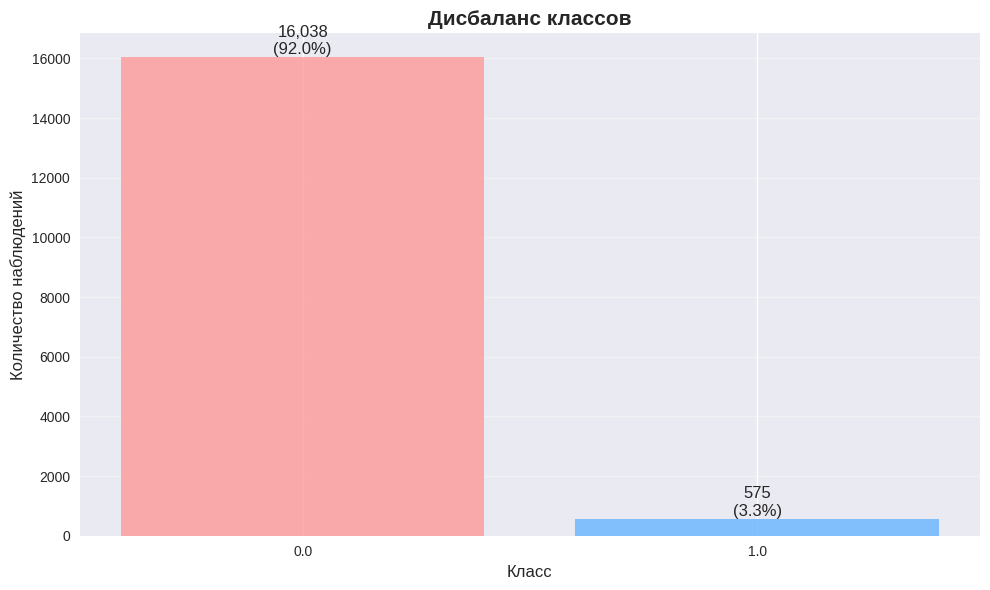

### 📈 Степень дисбаланса: 27.9:1

⚠️ **Сильный дисбаланс!** Требуются специальные методы обработки.

In [7]:
# Анализ дисбаланса классов
class_counts = df[target_variable].value_counts()
class_percentages = (class_counts / len(df)) * 100

display(Markdown("## ⚖️ Анализ дисбаланса классов"))
display(Markdown(f"### Целевая переменная: `{target_variable}`"))

# Создаем DataFrame для красивого отображения
balance_df = pd.DataFrame({
    'Класс': class_counts.index,
    'Количество': class_counts.values,
    'Процент': class_percentages.values
})
display(balance_df.style.background_gradient(cmap='Reds'))

# Визуализация дисбаланса
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(class_counts.index.astype(str), class_counts.values, 
              color=['#ff9999', '#66b3ff'], alpha=0.8)

# Добавляем значения над столбцами
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12)

ax.set_title('Дисбаланс классов', fontsize=15, fontweight='bold')
ax.set_xlabel('Класс', fontsize=12)
ax.set_ylabel('Количество наблюдений', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

imbalance_ratio = max(class_counts.values) / min(class_counts.values)
display(Markdown(f"### 📈 Степень дисбаланса: {imbalance_ratio:.1f}:1"))
if imbalance_ratio > 5:
    display(Markdown(f"⚠️ **Сильный дисбаланс!** Требуются специальные методы обработки."))
elif imbalance_ratio > 2:
    display(Markdown(f"🟡 **Умеренный дисбаланс.** Нужно учитывать при выборе метрик."))


In [10]:
display(Markdown("## 🕳️ Анализ пропущенных значений"))

## 🕳️ Анализ пропущенных значений

### 📊 Общая статистика по пропускам:

- Всего столбцов с пропусками: 31 из 31

- Средний процент пропусков: 43.37%

- Максимальный процент пропусков: 99.92%

### 🏆 Топ-20 столбцов с наибольшими пропусками:

,Столбец,Процент пропусков
10,ОНМК (гем) в анамнезе,99.919679
12,Открытая перация на сердце в анамнезе,99.707401
24,Плохая мобильность,99.707401
20,ЖКБ,99.638554
27,Стенокардия ФК (ИБ),97.664945
29,ФП постоянная форма,94.130809
30,ФП при окс (до чкв),94.119334
28,Форма ФП,83.671830
15,АГ,73.040734
11,Стентирование в анамнезе,72.667814


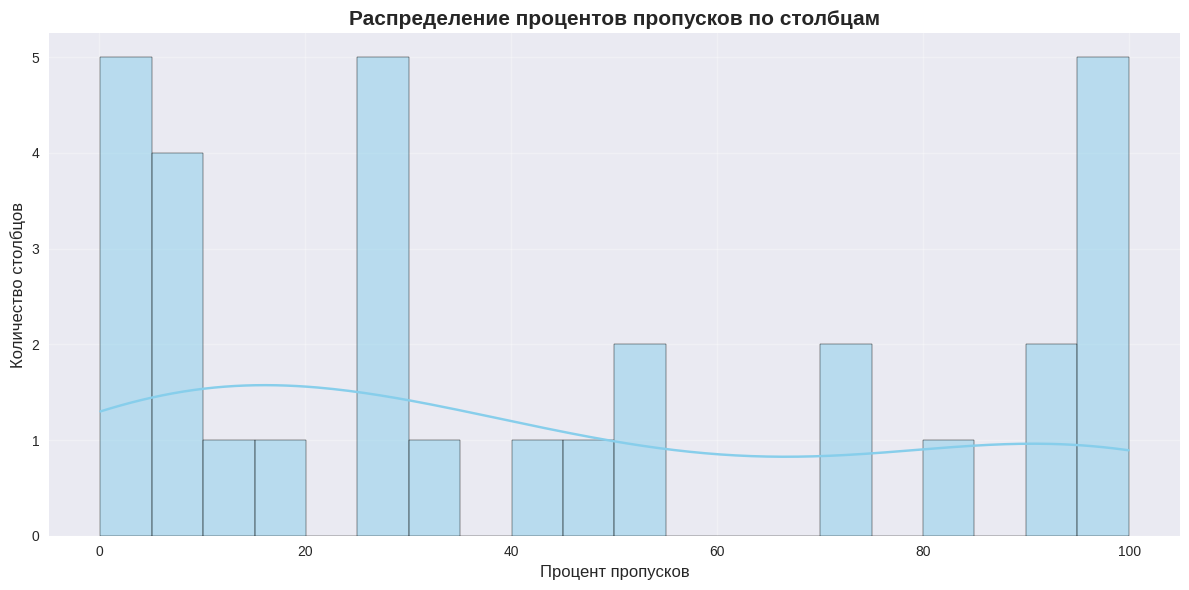

### 🎯 Анализ пропусков в контексте целевой переменной

#### Столбец: `ОНМК (гем) в анамнезе`

**Абсолютные значения:**

ОНМК (гем) в анамнезе,Значение,Пропуск,Всего
Смерть,,,
0.0,0,16038,16038
1.0,14,561,575
Всего,14,16599,16613


**Проценты:**

...

#### Столбец: `Стенокардия ФК (ИБ)`

**Абсолютные значения:**

Стенокардия ФК (ИБ),Значение,Пропуск,Всего
Смерть,,,
0.0,386,15652,16038
1.0,20,555,575
Всего,406,16207,16613


**Проценты:**

Стенокардия ФК (ИБ),Значение,Пропуск,Всего
Смерть,,,
0.000000,95.1%,96.6%,96.5%
1.000000,4.9%,3.4%,3.5%
Всего,100.0%,100.0%,100.0%


In [8]:
# Расчет процента пропусков для каждого столбца
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Столбец': missing_percentages.index,
    'Процент пропусков': missing_percentages.values
}).sort_values('Процент пропусков', ascending=False)

# Фильтруем столбцы с пропусками > 0%
missing_df = missing_df[missing_df['Процент пропусков'] > 0]

display(Markdown(f"### 📊 Общая статистика по пропускам:"))
display(Markdown(f"- Всего столбцов с пропусками: {len(missing_df)} из {len(df.columns)}"))
display(Markdown(f"- Средний процент пропусков: {missing_df['Процент пропусков'].mean():.2f}%"))
display(Markdown(f"- Максимальный процент пропусков: {missing_df['Процент пропусков'].max():.2f}%"))

# Показываем топ-20 столбцов с наибольшими пропусками
display(Markdown("### 🏆 Топ-20 столбцов с наибольшими пропусками:"))
display(missing_df.head(20).style.background_gradient(cmap='YlOrRd', subset=['Процент пропусков']))

# Визуализация распределения пропусков
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(missing_df['Процент пропусков'], bins=20, kde=True, color='skyblue', ax=ax)
ax.set_title('Распределение процентов пропусков по столбцам', fontsize=15, fontweight='bold')
ax.set_xlabel('Процент пропусков', fontsize=12)
ax.set_ylabel('Количество столбцов', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ пропусков по классам целевой переменной (если target известен)
if target_variable in df.columns:
    display(Markdown("### 🎯 Анализ пропусков в контексте целевой переменной"))
    
    # Выбираем несколько ключевых столбцов с пропусками для анализа
    key_missing_cols = missing_df.head(5)['Столбец'].tolist()
    
    for col in key_missing_cols:
        if col != target_variable:
            display(Markdown(f"#### Столбец: `{col}`"))
            
            # Создаем таблицу пропусков vs target
            missing_analysis = pd.crosstab(
                df[target_variable],
                df[col].isnull().map({True: 'Пропуск', False: 'Значение'}),
                margins=True,
                margins_name='Всего'
            )
            
            # Добавляем проценты
            missing_analysis_pct = missing_analysis.copy()
            for col_name in missing_analysis_pct.columns:
                missing_analysis_pct[col_name] = (missing_analysis_pct[col_name] / 
                                                missing_analysis_pct[col_name]['Всего'] * 100)
            
            display(Markdown("**Абсолютные значения:**"))
            display(missing_analysis)
            display(Markdown("**Проценты:**"))
            display(missing_analysis_pct.style.format("{:.1f}%"))

In [9]:
numeric_cols = df.select_dtypes(include=['float64']).columns
print(f"Собрано {len(numeric_cols)} цифровых колонок")

Собрано 7 цифровых колонок


In [10]:
target_variable = 'Смерть'

In [11]:
display(Markdown("## 🔍 Поиск утечек данных (data leaks)"))

# 1. Поиск признаков с очень высокой корреляцией с target
display(Markdown("### 📈 Поиск признаков с крайне высокой корреляцией с target"))

# Подготавливаем данные для корреляционного анализа
# Создаем копию для анализа, удаляя полностью пустые столбцы
df_analysis = df.copy()

# Удаляем столбцы с 100% пропусков
cols_to_drop = df_analysis.columns[df_analysis.isnull().mean() == 1.0]
if len(cols_to_drop) > 0:
    display(Markdown(f"Удаляем {len(cols_to_drop)} столбцов с 100% пропусков"))
    df_analysis = df_analysis.drop(columns=cols_to_drop)

# Фильтруем только числовые признаки для корреляционного анализа
numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()

# Удаляем target из списка числовых признаков для анализа
if target_variable in numeric_cols:
    numeric_cols.remove(target_variable)

display(Markdown(f"### Числовые признаки для анализа: {len(numeric_cols)} из {len(df_analysis.columns)}"))

# Вычисляем корреляции только для числовых признаков
if target_variable in df_analysis.columns and len(numeric_cols) > 0:
    # Преобразуем target в числовой формат для корреляции, если это категориальный признак
    if not pd.api.types.is_numeric_dtype(df_analysis[target_variable]):
        # Создаем временную числовую версию target
        target_numeric = df_analysis[target_variable].astype('category').cat.codes
    else:
        target_numeric = df_analysis[target_variable]
    
    # Вычисляем корреляции
    correlations = {}
    for col in numeric_cols:
        # Удаляем строки с пропусками для этой пары признаков
        temp_df = df_analysis[[col, target_variable]].dropna()
        
        if len(temp_df) > 10:  # минимальное количество наблюдений для корреляции
            try:
                corr = temp_df[col].corr(temp_df[target_variable])
                if not np.isnan(corr):
                    correlations[col] = corr
            except:
                continue
    if correlations:
        # Создаем DataFrame с корреляциями
        corr_df = pd.DataFrame({
            'Признак': list(correlations.keys()),
            'Корреляция с target': list(correlations.values())
        }).sort_values('Корреляция с target', key=abs, ascending=False)
        
        # Выделяем признаки с очень высокой корреляцией (потенциальные утечки)
        high_corr_threshold = 0.85
        potential_leaks = corr_df[abs(corr_df['Корреляция с target']) >= high_corr_threshold]
        
        display(Markdown("### 📊 Топ-20 признаков по корреляции с target:"))
        display(corr_df.head(20).style.background_gradient(cmap='coolwarm', subset=['Корреляция с target'], vmin=-1, vmax=1))
        
        if not potential_leaks.empty:
            display(Markdown(f"### ⚠️ **ПОТЕНЦИАЛЬНЫЕ УТЕЧКИ ДАННЫХ** (|корреляция| >= {high_corr_threshold}):"))
            display(potential_leaks.style.background_gradient(cmap='Reds', subset=['Корреляция с target']))
            
            # Визуализация топ корреляций
            plt.figure(figsize=(14, 8))
            top_corr = corr_df.head(25)
            bars = plt.barh(top_corr['Признак'], top_corr['Корреляция с target'], 
                           color=['#ff4444' if abs(x) >= high_corr_threshold else '#4488ff' for x in top_corr['Корреляция с target']])
            
            plt.axvline(x=high_corr_threshold, color='r', linestyle='--', alpha=0.7, label=f'Порог утечки ({high_corr_threshold})')
            plt.axvline(x=-high_corr_threshold, color='r', linestyle='--', alpha=0.7)
            
            plt.title(f'Топ-25 корреляций с целевой переменной "{target_variable}"', fontsize=15, fontweight='bold')
            plt.xlabel('Корреляция с target', fontsize=12)
            plt.ylabel('Признаки', fontsize=12)
            plt.grid(axis='x', alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("✅ Не обнаружено признаков с экстремально высокой корреляцией (потенциальных утечек)"))
    else:
        display(Markdown("❌ Не удалось вычислить корреляции. Проверьте типы данных и наличие пропусков."))


## 🔍 Поиск утечек данных (data leaks)

### 📈 Поиск признаков с крайне высокой корреляцией с target

### Числовые признаки для анализа: 6 из 31

### 📊 Топ-20 признаков по корреляции с target:

,Признак,Корреляция с target
0,Age,0.118773
5,ГБ риск,0.062216
4,ГБ стадия,0.055820
2,Вес,-0.042440
1,Рост,-0.029776
3,Индекс массы тела,-0.028389


✅ Не обнаружено признаков с экстремально высокой корреляцией (потенциальных утечек)

In [12]:
display(Markdown("## 🏷️ Анализ категориальных признаков на предмет утечек"))

# Находим категориальные признаки
categorical_cols = df_analysis.select_dtypes(include=['object', 'category']).columns.tolist()
if target_variable in categorical_cols:
    categorical_cols.remove(target_variable)

display(Markdown(f"### Категориальные признаки для анализа: {len(categorical_cols)}"))

# Анализ категориальных признаков на предмет идеального разделения классов
if target_variable in df_analysis.columns and len(categorical_cols) > 0 and df_analysis[target_variable].nunique() == 2:
    display(Markdown("### 🔍 Поиск категориальных признаков с идеальным разделением классов"))
    
    potential_cat_leaks = []
    target_classes = df_analysis[target_variable].unique()
    target_classes = target_classes[~pd.isna(target_classes)]
    
    if len(target_classes) == 2:
        for col in categorical_cols:
            if df_analysis[col].nunique() < 20:  # ограничиваем для управляемости
                # Создаем таблицу сопряженности
                cross_tab = pd.crosstab(df_analysis[col], df_analysis[target_variable])
                
                if cross_tab.shape[0] > 1 and cross_tab.shape[1] == 2:
                    # Проверяем, есть ли категории, которые встречаются только в одном классе
                    for category in cross_tab.index:
                        row = cross_tab.loc[category]
                        if (row.iloc[0] == 0 and row.iloc[1] > 0) or (row.iloc[0] > 0 and row.iloc[1] == 0):
                            if row.sum() > 10:  # минимальное количество наблюдений
                                leak_ratio = max(row) / row.sum()
                                if leak_ratio > 0.95:  # 95% и более наблюдений в одной категории
                                    potential_cat_leaks.append({
                                        'Признак': col,
                                        'Категория': str(category),
                                        'Распределение': row.values.tolist(),
                                        'Процент в одном классе': leak_ratio * 100
                                    })
    
    if potential_cat_leaks:
        leak_df = pd.DataFrame(potential_cat_leaks)
        display(Markdown(f"### ⚠️ **ПОТЕНЦИАЛЬНЫЕ УТЕЧКИ в категориальных признаках** (95%+ наблюдений в одном классе):"))
        display(leak_df.style.background_gradient(cmap='Reds', subset=['Процент в одном классе']))
    else:
        display(Markdown("✅ Не обнаружено категориальных признаков с идеальным разделением классов"))


## 🏷️ Анализ категориальных признаков на предмет утечек

### Категориальные признаки для анализа: 24

### 🔍 Поиск категориальных признаков с идеальным разделением классов

✅ Не обнаружено категориальных признаков с идеальным разделением классов

## 📐 Анализ мультиколлинеарности признаков

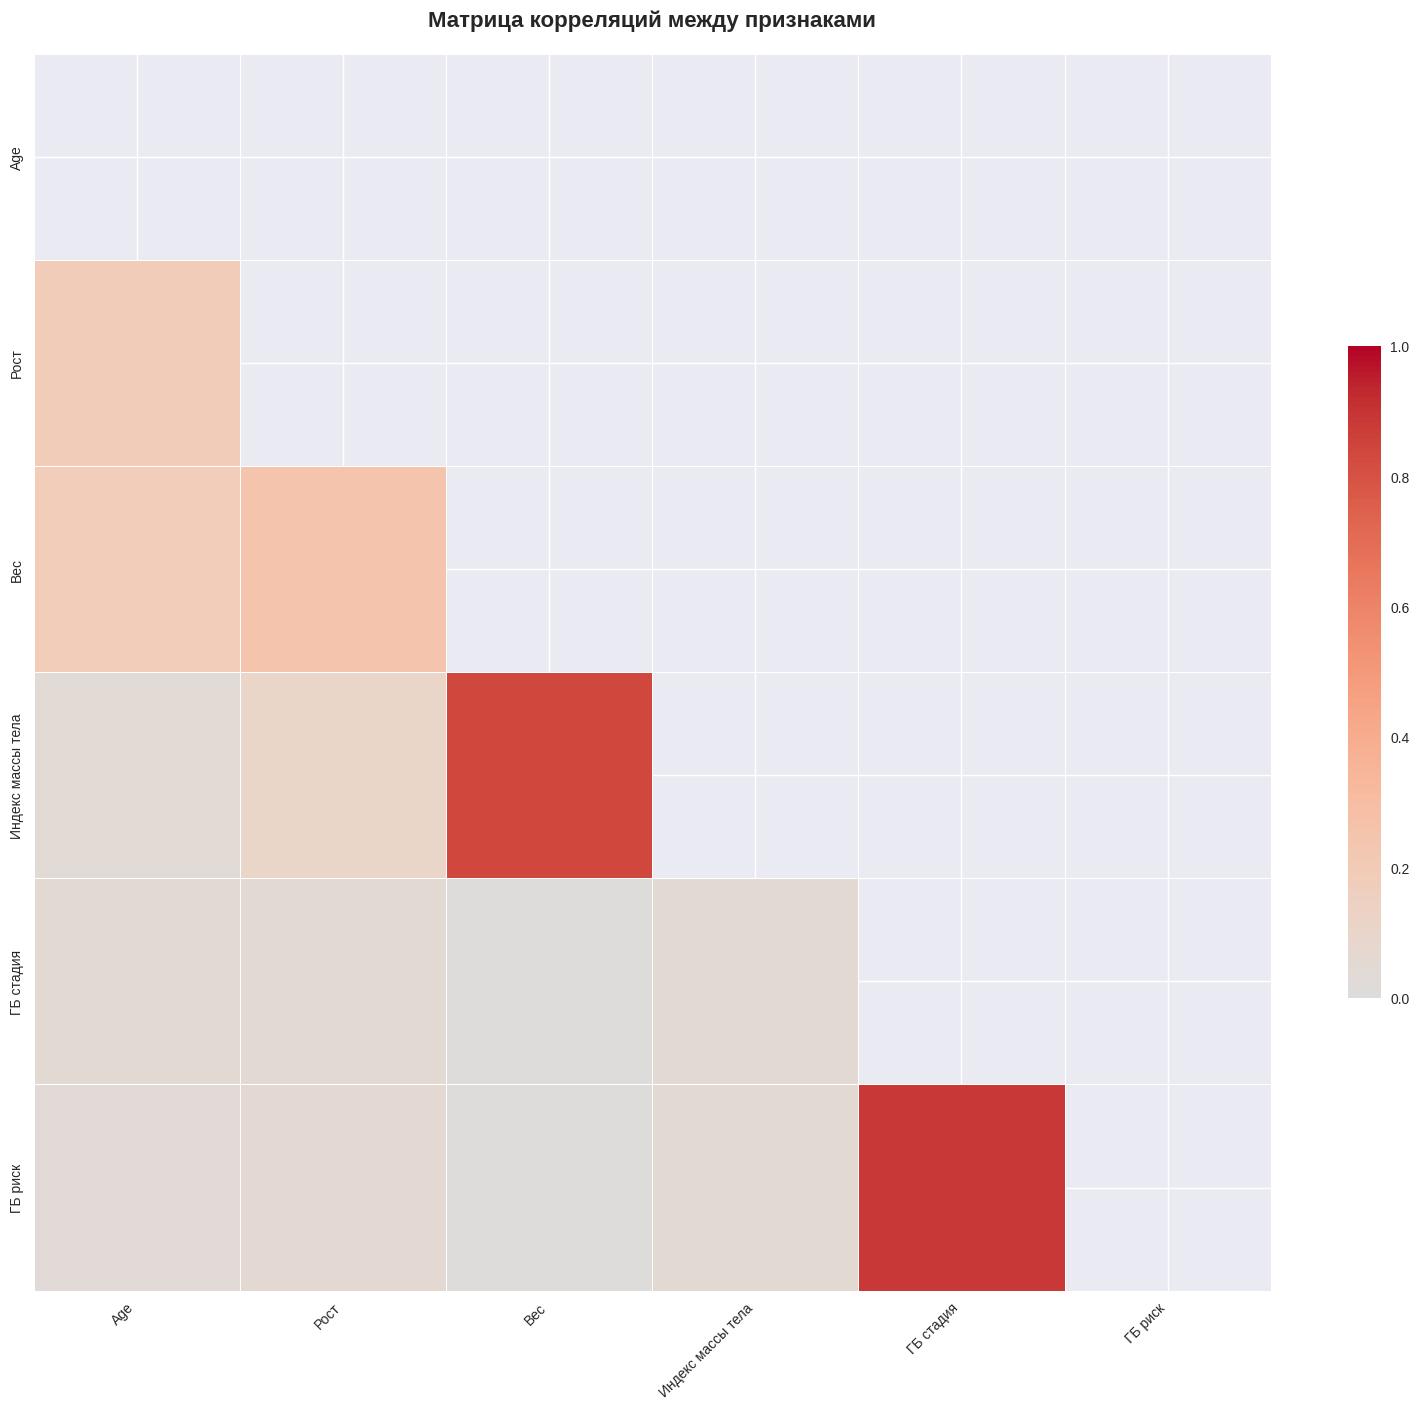

✅ Не обнаружено признаков с экстремально высокой корреляцией между собой

In [13]:
display(Markdown("## 📐 Анализ мультиколлинеарности признаков"))

# Вычисляем мультиколлинеарность для числовых признаков
if len(numeric_cols) > 10:
    display(Markdown(f"⚠️ Слишком много числовых признаков ({len(numeric_cols)}) для полного анализа мультиколлинеарности"))
    display(Markdown("Будем анализировать только топ-50 признаков по корреляции с target"))
    
    # Берем топ-50 признаков по корреляции с target
    top_features = corr_df.head(50)['Признак'].tolist() if 'corr_df' in locals() else numeric_cols[:50]
else:
    top_features = numeric_cols

if len(top_features) > 1:
    # Создаем матрицу корреляций для топ признаков
    corr_matrix = df_analysis[top_features].corr().abs()
    
    # Визуализация тепловой карты
    plt.figure(figsize=(16, 14))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=False,
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": .5},
                vmin=0,
                vmax=1)
    
    plt.title('Матрица корреляций между признаками', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Находим пары признаков с очень высокой корреляцией
    high_corr_pairs = []
    threshold = 0.95
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] > threshold:
                high_corr_pairs.append({
                    'Признак 1': corr_matrix.columns[i],
                    'Признак 2': corr_matrix.columns[j],
                    'Корреляция': corr_matrix.iloc[i, j]
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Корреляция', ascending=False)
        display(Markdown(f"### ⚠️ Признаки с очень высокой корреляцией (> {threshold}):"))
        display(high_corr_df.style.background_gradient(cmap='Oranges', subset=['Корреляция']))
    else:
        display(Markdown("✅ Не обнаружено признаков с экстремально высокой корреляцией между собой"))


## 📈 Анализ распределений признаков по классам target

### Распределения топ-6 признаков по классам target:

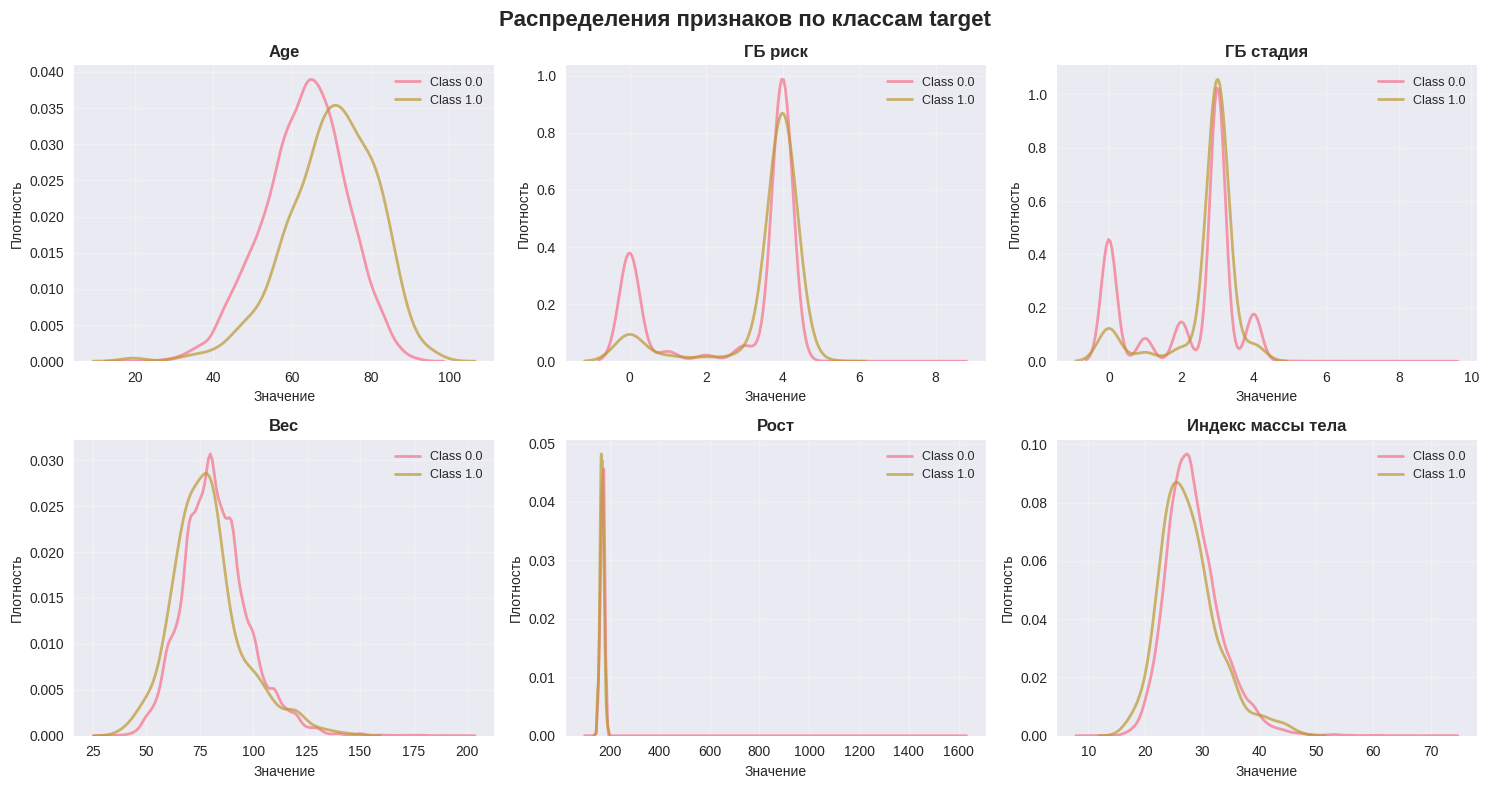

In [14]:
display(Markdown("## 📈 Анализ распределений признаков по классам target"))

# Анализируем распределения для топ признаков по корреляции
if target_variable in df_analysis.columns and len(numeric_cols) > 0:
    # Берем топ-10 признаков по корреляции с target
    top_analysis_features = corr_df.head(10)['Признак'].tolist() if 'corr_df' in locals() else numeric_cols[:10]
    
    # Удаляем признаки, которые являются потенциальными утечками
    if 'potential_leaks' in locals() and not potential_leaks.empty:
        leak_features = potential_leaks['Признак'].tolist()
        top_analysis_features = [f for f in top_analysis_features if f not in leak_features]
    
    if top_analysis_features:
        display(Markdown(f"### Распределения топ-{len(top_analysis_features)} признаков по классам target:"))
        
        # Создаем фигуру с подграфиками
        n_features = len(top_analysis_features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), 
                                squeeze=False, tight_layout=True)
        
        # Извлекаем классы target
        target_classes = df_analysis[target_variable].unique()
        target_classes = target_classes[~pd.isna(target_classes)]
        
        for i, feature in enumerate(top_analysis_features):
            row = i // n_cols
            col = i % n_cols
            ax = axes[row, col]
            
            # Строим распределения для каждого класса
            for class_val in target_classes:
                class_data = df_analysis[df_analysis[target_variable] == class_val][feature]
                class_data = class_data.replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(class_data) > 10:
                    sns.kdeplot(class_data, ax=ax, label=f'Class {class_val}', 
                               alpha=0.7, linewidth=2)
            
            ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Значение', fontsize=10)
            ax.set_ylabel('Плотность', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
        # Скрываем пустые subplot
        for i in range(len(top_analysis_features), n_rows * n_cols):
            row = i // n_cols
            col = i % n_cols
            axes[row, col].set_visible(False)
        
        plt.suptitle('Распределения признаков по классам target', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, auc
import re
from collections import Counter

In [16]:
display(Markdown("## 🎯 Цели предобработки:"))
display(Markdown("""
1. **Сократить 465 признаков** до 20-50 наиболее значимых
2. **Обработать пропуски** без импутации (только удаление и индикаторы)
3. **Подготовить данные** для работы с дисбалансом 97%/3%
4. **Удалить вредные признаки** (только в одном классе, пустые, избыточные)
5. **Сохранить медицинский смысл** оставшихся признаков
"""))

## 🎯 Цели предобработки:


1. **Сократить 465 признаков** до 20-50 наиболее значимых
2. **Обработать пропуски** без импутации (только удаление и индикаторы)
3. **Подготовить данные** для работы с дисбалансом 97%/3%
4. **Удалить вредные признаки** (только в одном классе, пустые, избыточные)
5. **Сохранить медицинский смысл** оставшихся признаков


In [16]:
# Проверяем, что у нас есть df из предыдущих шагов
if 'df' not in globals():
    display(Markdown("❌ **Данные не загружены!** Выполните сначала ячейки с EDA и загрузкой данных."))
else:
    display(Markdown("✅ **Данные доступны из предыдущих шагов**"))
    display(Markdown(f"Текущий размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов"))


✅ **Данные доступны из предыдущих шагов**

Текущий размер данных: 17430 строк, 6 столбцов

In [18]:
TARGET_VARIABLE = target_variable

In [16]:
df_prep = df.copy()

In [17]:
initial_count = len(df_prep)
df_prep = df_prep.dropna(subset=[target_variable])
removed_target_missing = initial_count - len(df_prep)

if removed_target_missing > 0:
    display(Markdown(f"### 🗑️ Удалено {removed_target_missing} строк с пропусками в целевой переменной"))

### 🗑️ Удалено 817 строк с пропусками в целевой переменной

In [18]:
y = df_prep[target_variable].astype(int)
class_counts = y.value_counts()
    
display(Markdown("## ⚖️ Финальный дисбаланс классов:"))
balance_df = pd.DataFrame({
    'Класс': class_counts.index,
    'Количество': class_counts.values,
    'Процент': (class_counts / len(y) * 100).values
})
display(balance_df.style.background_gradient(cmap='Reds'))

if len(class_counts) < 2:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ОШИБКА: Остался только один класс!**"))
elif min(class_counts) < 10:
    display(Markdown(f"⚠️ **ОПАСНЫЙ ДИСБАЛАНС: В minority классе всего {min(class_counts)} наблюдений!**"))


## ⚖️ Финальный дисбаланс классов:

,Класс,Количество,Процент
0,0,16038,96.538855
1,1,575,3.461145


In [21]:
display(Markdown("## 🕳️ Шаг 2: Стратегическая обработка пропусков"))

## 🕳️ Шаг 2: Стратегическая обработка пропусков

In [19]:
X = df_prep.drop(columns=[target_variable])

# 2.1 Удаление признаков с экстремальным количеством пропусков (>70%)
missing_percentages = (X.isnull().sum() / len(X)) * 100
high_missing_threshold = 70  # 70% пропусков как порог для удаления
cols_to_drop_high_missing = missing_percentages[missing_percentages > high_missing_threshold].index.tolist()

if cols_to_drop_high_missing:
    display(Markdown(f"### 🗑️ Удаляем {len(cols_to_drop_high_missing)} признаков с >{high_missing_threshold}% пропусков:"))
    display(Markdown(f"{cols_to_drop_high_missing[:10]}{'...' if len(cols_to_drop_high_missing) > 10 else ''}"))
    X = X.drop(columns=cols_to_drop_high_missing)
else:
    display(Markdown("✅ Нет признаков для удаления по критерию >70% пропусков"))

### 🗑️ Удаляем 10 признаков с >70% пропусков:

['ОНМК (гем) в анамнезе', 'Стентирование в анамнезе', 'Открытая перация на сердце в анамнезе', 'АГ', 'ЖКБ', 'Плохая мобильность', 'Стенокардия ФК (ИБ)', 'Форма ФП', 'ФП постоянная форма', 'ФП при окс (до чкв)']

In [20]:
X_raw = X.copy()  # Сохраняем исходные данные перед обработкой
y_raw = y.copy()

In [21]:
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

In [22]:
display(Markdown(f"### 📊 Распределение типов признаков:"))
display(Markdown(f"- **Числовых признаков:** {len(numeric_cols)}"))
display(Markdown(f"- **Категориальных признаков:** {len(categorical_cols)}"))
display(Markdown(f"- **Всего признаков:** {len(X_raw.columns)}"))

### 📊 Распределение типов признаков:

- **Числовых признаков:** 6

- **Категориальных признаков:** 14

- **Всего признаков:** 20

In [23]:
# Показываем примеры категориальных признаков
if categorical_cols:
    display(Markdown("### 🔍 Примеры категориальных признаков:"))
    for col in categorical_cols[:5]:
        unique_vals = X_raw[col].dropna().unique()[:5]
        display(Markdown(f"- `{col}`: примеры значений {unique_vals}{'...' if len(unique_vals) > 5 else ''}"))
else:
    display(Markdown("✅ Нет категориальных признаков для обработки"))

### 🔍 Примеры категориальных признаков:

- `Sex`: примеры значений ['М' 'Ж']

- `Инфаркт миокарда в анамнезе (<3)`: примеры значений ['Нет' 'Да']

- `Инфаркт миокарда в анамнезе (>3)`: примеры значений ['Нет' 'Да']

- `Инфаркт миокарда со стентированием в анамнезе`: примеры значений ['Нет' 'Да']

- `ОНМК (иш) в анамнезе`: примеры значений ['Нет' 'Да']

In [67]:
display(Markdown("### 🔄 Кодирование категориальных признаков"))

### 🔄 Кодирование категориальных признаков

In [24]:
X_encoded = X_raw.copy()

In [25]:
for col in categorical_cols:
    # Считаем количество уникальных значений
    n_unique = X_encoded[col].nunique()
    n_samples = len(X_encoded)
    
    # Выбираем стратегию кодирования
    if n_unique == 2:
        # Бинарное кодирование для бинарных признаков
        unique_vals = X_encoded[col].dropna().unique()
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        X_encoded[col] = X_encoded[col].map(mapping)
        display(Markdown(f"✅ Бинарное кодирование: `{col}` → 0/1"))
        
    elif n_unique <= 10:
        # One-hot encoding для признаков с малым количеством категорий
        dummies = pd.get_dummies(X_encoded[col], prefix=col, drop_first=True)
        X_encoded = pd.concat([X_encoded, dummies], axis=1)
        X_encoded = X_encoded.drop(columns=[col])
        display(Markdown(f"✅ One-hot encoding: `{col}` → {len(dummies.columns)} новых признаков"))
        
    else:
        # Frequency encoding для признаков с большим количеством категорий
        freq_map = X_encoded[col].value_counts(normalize=True)
        X_encoded[f"{col}_freq"] = X_encoded[col].map(freq_map)
        X_encoded = X_encoded.drop(columns=[col])
        display(Markdown(f"✅ Frequency encoding: `{col}` → частотное представление"))

display(Markdown(f"### 📈 Размер после кодирования: {X_encoded.shape[0]} строк, {X_encoded.shape[1]} столбцов"))

✅ Бинарное кодирование: `Sex` → 0/1

✅ Бинарное кодирование: `Инфаркт миокарда в анамнезе (<3)` → 0/1

✅ Бинарное кодирование: `Инфаркт миокарда в анамнезе (>3)` → 0/1

✅ Бинарное кодирование: `Инфаркт миокарда со стентированием в анамнезе` → 0/1

✅ Бинарное кодирование: `ОНМК (иш) в анамнезе` → 0/1

...

✅ Бинарное кодирование: `Курит` → 0/1

✅ Бинарное кодирование: `Экстракардиальная артериопатия` → 0/1

✅ Бинарное кодирование: `Стенокардия (ИБ)` → 0/1

✅ One-hot encoding: `Стенокардия форма(ИБ)` → 2 новых признаков

### 📈 Размер после кодирования: 16613 строк, 21 столбцов

In [26]:
X = X_encoded.copy()

In [27]:
# 2.2 Удаление пустых и константных признаков
empty_cols = X.columns[X.isnull().all()].tolist()
if empty_cols:
    display(Markdown(f"Удаляем пустые признаки: {empty_cols}"))
    X = X.drop(columns=empty_cols)

constant_cols = X.columns[X.nunique() == 1].tolist()
if constant_cols:
    display(Markdown(f"Удаляем константные признаки: {constant_cols[:5]}{'...' if len(constant_cols) > 5 else ''}"))
    X = X.drop(columns=constant_cols)

In [26]:
display(Markdown("### 🔍 Поиск признаков, присутствующих только в одном классе"))

### 🔍 Поиск признаков, присутствующих только в одном классе

In [31]:
# Работаем только с числовыми признаками для этой проверки
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
one_class_features = []

for col in numeric_cols:
    # Проверяем наличие значений в каждом классе
    class_0_data = X[y == 0][col]
    class_1_data = X[y == 1][col]
    
    count_0 = class_0_data.count()
    count_1 = class_1_data.count()
    
    # Если признак есть только в одном классе и имеет достаточно наблюдений
    if (count_0 == 0 and count_1 >= 5) or (count_1 == 0 and count_0 >= 5):
        one_class_features.append({
            'feature': col,
            'class_0_count': count_0,
            'class_1_count': count_1,
            'only_in_class': 1 if count_0 == 0 else 0
        })

In [32]:
if one_class_features:
    one_class_df = pd.DataFrame(one_class_features)
    display(Markdown(f"### ⚠️ Найдено {len(one_class_features)} признаков, присутствующих только в одном классе:"))
    display(one_class_df.style.background_gradient(cmap='Reds'))
    
    # Удаляем такие признаки
    features_to_drop = one_class_df['feature'].tolist()
    display(Markdown(f"**Удаляем {len(features_to_drop)} признаков как потенциальные скрытые утечки**"))
    X = X.drop(columns=features_to_drop)
else:
    display(Markdown("✅ Не обнаружено признаков, присутствующих только в одном классе"))

✅ Не обнаружено признаков, присутствующих только в одном классе

In [29]:
display(Markdown("### 🚩 Создание индикаторов пропусков"))

### 🚩 Создание индикаторов пропусков

In [31]:
# Сначала определим важные признаки через корреляцию (только числовые)
important_features = []
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    correlations = {}
    for col in numeric_cols:
        temp_df = pd.concat([X[col], y], axis=1).dropna()
        if len(temp_df) > 10:  # минимальное количество наблюдений
            try:
                # ГАРАНТИРУЕМ ЧИСЛОВОЙ ФОРМАТ ДЛЯ КОРРЕЛЯЦИИ
                col_values = pd.to_numeric(temp_df[col], errors='coerce')
                target_values = pd.to_numeric(temp_df.iloc[:, 1], errors='coerce')
                
                valid_data = pd.concat([col_values, target_values], axis=1).dropna()
                
                if len(valid_data) > 10 and valid_data.iloc[:, 0].nunique() > 1:
                    corr = valid_data.iloc[:, 0].corr(valid_data.iloc[:, 1])
                    if not np.isnan(corr):
                        correlations[col] = abs(corr)
            except Exception as e:
                continue  # Пропускаем проблемные признаки
    
    if correlations:
        # Берем топ-20 признаков по корреляции
        important_features = sorted(correlations.items(), key=lambda x: x[1], reverse=True)[:20]
        important_features = [feat for feat, _ in important_features]
        display(Markdown(f"### Важные признаки для индикаторов пропусков: {len(important_features)} - {important_features}"))
    else:
        # Если корреляция не работает, берем первые 20 числовых признаков
        important_features = numeric_cols[:20]
        display(Markdown("ℹ️ Не удалось вычислить корреляции - используем первые 20 числовых признаков"))


### Важные признаки для индикаторов пропусков: 20 - ['LACTartMax (a)', 'LACTartMax', 'LACTartMax (b)', 'LactVenMax (a)', 'LACTartMin (a)', 'LactVenMax', 'LACTartMin', 'LACTartMin (b)', 'LactVenMin (a)', 'LactVenMin', 'Apache II', 'killip', 'АСАТ(a)', 'АЛАТ(a)', 'GRACE(Общее)', 'GRACE(Общее)>156', 'Нейтрофилы (абсолютное значение)', 'Нейтрофилы (абсолютное значение)(a)', 'Класс ОСН по Killip', 'КФК(a)']

In [32]:
# Создаем индикаторы пропусков
missing_indicators_created = 0
for feature in important_features:
    if feature in X.columns:
        missing_count = X[feature].isnull().sum()
        if 0 < missing_count < len(X):  # есть и пропуски, и значения
            missing_col_name = f"{feature}_missing"
            if missing_col_name not in X.columns:
                X[missing_col_name] = X[feature].isnull().astype(int)
                missing_indicators_created += 1

if missing_indicators_created > 0:
    display(Markdown(f"### ✅ Создано {missing_indicators_created} индикаторов пропусков"))
else:
    display(Markdown("✅ Индикаторы пропусков не требуются (нет пропусков в важных признаках)"))

### ✅ Создано 20 индикаторов пропусков

In [33]:
display(Markdown("## 🔍 Шаг 3: Отбор признаков"))

## 🔍 Шаг 3: Отбор признаков

In [34]:
display(Markdown("### 📐 Устранение мультиколлинеарности"))

### 📐 Устранение мультиколлинеарности

In [33]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
features_to_remove_corr = []

In [34]:
if len(numeric_cols) > 5:
    # Создаем копию для анализа корреляций
    X_corr = X[numeric_cols].copy()
    
    # Удаляем пропуски ТОЛЬКО ДЛЯ АНАЛИЗА КОРРЕЛЯЦИЙ
    # X_corr_clean = X_corr.dropna()
    X_corr_clean = X_corr
    
    if len(X_corr_clean) > 10:
        corr_matrix = X_corr_clean.corr().abs()
        
        # Находим пары признаков с корреляцией > 0.85
        high_corr_threshold = 0.85
        high_corr_pairs = []
        
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if corr_matrix.iloc[i, j] > high_corr_threshold:
                    high_corr_pairs.append({
                        'feature1': corr_matrix.columns[i],
                        'feature2': corr_matrix.columns[j],
                        'correlation': corr_matrix.iloc[i, j]
                    })
        
        if high_corr_pairs:
            high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
            display(Markdown(f"### Найдено {len(high_corr_pairs)} пар признаков с корреляцией > {high_corr_threshold}:"))
            
            # Удаляем один из пары - тот, у которого меньше корреляция с target
            for _, row in high_corr_df.iterrows():
                if row['feature1'] in X.columns and row['feature2'] in X.columns:
                    # Вычисляем корреляцию с target (гарантируем числовой формат)
                    temp_df1 = pd.concat([X[row['feature1']], y], axis=1).dropna()
                    temp_df2 = pd.concat([X[row['feature2']], y], axis=1).dropna()

                    if len(temp_df1) > 10 and len(temp_df2) > 10:
                        try:
                            # Приводим к числовому формату
                            feat1_num = pd.to_numeric(temp_df1.iloc[:, 0], errors='coerce')
                            feat2_num = pd.to_numeric(temp_df2.iloc[:, 0], errors='coerce')
                            target_num = pd.to_numeric(temp_df1.iloc[:, 1], errors='coerce')
                            
                            valid1 = pd.concat([feat1_num, target_num], axis=1).dropna()
                            valid2 = pd.concat([feat2_num, target_num], axis=1).dropna()
                            
                            if len(valid1) > 10 and len(valid2) > 10:
                                corr1 = valid1.iloc[:, 0].corr(valid1.iloc[:, 1])
                                corr2 = valid2.iloc[:, 0].corr(valid2.iloc[:, 1])
                                
                                # Выбираем признак с меньшей корреляцией к target для удаления
                                feature_to_remove = row['feature1'] if abs(corr1) < abs(corr2) else row['feature2']
                                if feature_to_remove not in features_to_remove_corr:
                                    features_to_remove_corr.append(feature_to_remove)
                        except:
                            continue
        
        if features_to_remove_corr:
            display(Markdown(f"### 🗑️ Удаляем {len(features_to_remove_corr)} мультиколлинеарных признаков:"))
            display(Markdown(f"{features_to_remove_corr[:10]}{'...' if len(features_to_remove_corr) > 10 else ''}"))
            X = X.drop(columns=features_to_remove_corr)
        else:
            display(Markdown("✅ Не обнаружено сильно коррелирующих признаков для удаления"))
    else:
        display(Markdown("ℹ️ Недостаточно данных для анализа мультиколлинеарности"))
else:
    display(Markdown("ℹ️ Недостаточно числовых признаков для анализа мультиколлинеарности"))

### Найдено 176 пар признаков с корреляцией > 0.85:

### 🗑️ Удаляем 69 мультиколлинеарных признаков:

['Класс ОСН по Killip', 'pHARTmax', 'pO2ARTmin (b)', 'pO2ARTmax (b)', 'pCO2min (b)', 'pHARTmin (b)', 'pCO2max', 'HCO3ArtMax (b)', 'BEArtMax (b)', 'HCO3ArtMin (b)']...

In [40]:
display(Markdown("### 🎯 Финальный отбор признаков"))

### 🎯 Финальный отбор признаков

In [28]:
final_features = X.columns.tolist()

In [36]:
# Если признаков слишком много (>50), оставляем только лучшие
if len(final_features) > 50:
    # Используем только числовые признаки для отбора
    numeric_final = X.select_dtypes(include=[np.number]).columns.tolist()
    
    if numeric_final:
        # Быстрая оценка важности через корреляцию с target
        feature_scores = {}
        for col in numeric_final:
            temp_df = pd.concat([X[col], y], axis=1).dropna()
            if len(temp_df) > 10:
                try:
                    col_num = pd.to_numeric(temp_df[col], errors='coerce')
                    target_num = pd.to_numeric(temp_df.iloc[:, 1], errors='coerce')
                    valid_data = pd.concat([col_num, target_num], axis=1).dropna()
                    
                    if len(valid_data) > 10 and valid_data.iloc[:, 0].nunique() > 1:
                        corr = valid_data.iloc[:, 0].corr(valid_data.iloc[:, 1])
                        if not np.isnan(corr):
                            feature_scores[col] = abs(corr)
                except:
                    continue
        
        if feature_scores:
            # Берем топ-50 признаков
            top_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)[:50]
            final_features = [feat for feat, _ in top_features]
            
            # Добавляем индикаторы пропусков
            missing_indicators = [col for col in X.columns if col.endswith('_missing')]
            final_features.extend([col for col in missing_indicators if col not in final_features])
            
            display(Markdown(f"### ✅ Отобрано {len(final_features)} наиболее значимых признаков"))
        else:
            # Если корреляция не работает, берем первые 50 признаков
            final_features = X.columns[:50].tolist()
            display(Markdown("ℹ️ Не удалось оценить важность признаков - используем первые 50 признаков"))
    else:
        final_features = X.columns[:50].tolist()

display(Markdown(f"### 📊 Финальные признаки для моделирования: {len(final_features)}"))
display(Markdown(f"{final_features[:20]}{'...' if len(final_features) > 20 else ''}"))

### ✅ Отобрано 50 наиболее значимых признаков

### 📊 Финальные признаки для моделирования: 50

['LACTartMax (a)', 'LactVenMax (a)', 'LACTartMin (a)', 'Apache II', 'killip', 'АСАТ(a)', 'Адреналин', 'Отек легких', 'Отек легких(a)', 'GRACE(Общее)', 'Норадреналин', 'GRACE(Общее)>156', 'Нейтрофилы (абсолютное значение)(a)', 'КФК(a)', 'Креатинин', 'CADILLAC', 'PAMI', 'SaO2min (a)', 'Лейкоциты', 'Креатинин(b)']...

In [46]:
display(Markdown("## 📊 Шаг 4: Стратифицированное разделение данных"))

## 📊 Шаг 4: Стратифицированное разделение данных

In [44]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [45]:
X_final = X_clean.copy()
y_final = y.copy()

In [46]:
total_missing = X_final.isnull().sum().sum()

In [47]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
            X_final, y_final,
            test_size=0.2,
            stratify=y_final,
            random_state=42
        )

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

In [49]:
X_train

,Age,Sex,Рост,Вес,Индекс_массы_тела,Инфаркт_миокарда_в_анамнезе_lt_3,Инфаркт_миокарда_в_анамнезе_gt_3,Инфаркт_миокарда_со_стентированием_в_анамнезе,ОНМК_иш_в_анамнезе,ГБ_стадия,ГБ_риск,СД,ХБП,ЯБ,МКБ,ХОБЛ_Новый_столбец,Курит,Экстракардиальная_артериопатия,Стенокардия_ИБ,Стенокардия_форма_ИБ_Нет,Стенокардия_форма_ИБ_Стабильная
12998,54.0,0.0,190.0,95.0,26.320000,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,False,True
15288,77.0,1.0,175.0,85.0,27.760000,0.0,0.0,NaN,NaN,3.0,4.0,1.0,0.0,0.0,0.0,NaN,NaN,1.0,NaN,False,True
5071,81.0,1.0,164.0,84.0,26.790000,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,False,False
13167,75.0,1.0,160.0,65.0,25.390000,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,False,True
2830,72.0,0.0,170.0,68.0,NaN,0.0,0.0,0.0,0.0,3.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15957,51.0,0.0,171.0,114.0,38.990000,0.0,0.0,NaN,NaN,3.0,4.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,NaN,False,True
7875,79.0,1.0,169.0,89.0,31.161374,0.0,0.0,0.0,NaN,NaN,NaN,1.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,False,False
17038,64.0,0.0,175.0,85.0,27.755102,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,1.0,NaN,0.0,False,False
2229,54.0,1.0,158.0,80.0,32.046146,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,False,False


In [50]:
display(Markdown("### ✅ Успешное разделение данных!"))
display(Markdown(f"**Размеры наборов:**"))
display(Markdown(f"- Train: {len(X_train)} ({sum(y_train == 1)/len(y_train)*100:.1f}% класса 1)"))
display(Markdown(f"- Validation: {len(X_val)} ({sum(y_val == 1)/len(y_val)*100:.1f}% класса 1)"))
display(Markdown(f"- Test: {len(X_test)} ({sum(y_test == 1)/len(y_test)*100:.1f}% класса 1)"))

### ✅ Успешное разделение данных!

**Размеры наборов:**

- Train: 9967 (3.5% класса 1)

- Validation: 3323 (3.5% класса 1)

- Test: 3323 (3.5% класса 1)

In [51]:
strat_check = pd.DataFrame({
    'Набор': ['Train', 'Validation', 'Test'],
    'Процент класса 1': [
        sum(y_train == 1)/len(y_train)*100,
        sum(y_val == 1)/len(y_val)*100,
        sum(y_test == 1)/len(y_test)*100
    ]
})
display(Markdown("**Проверка стратификации (процент minority класса):**"))
display(strat_check.style.background_gradient(cmap='Greens'))

**Проверка стратификации (процент minority класса):**

,Набор,Процент класса 1
0,Train,3.461423
1,Validation,3.460728
2,Test,3.460728


------------------------------

In [53]:
# Базовая информация о данных
display(Markdown("## 📊 Базовая информация о датасете"))

# Информация о типах данных
display(Markdown("### 💾 Информация о типах данных"))
buffer = pd.io.common.StringIO()
X_final.info(buf=buffer)
info_str = buffer.getvalue()
display(Markdown(f"```\n{info_str}\n```"))

info_df = pd.DataFrame({
    'Column': X_final.columns,
    'Type': X_final.dtypes.astype(str),
    'First Value': X_final.iloc[0].values,
    'Last Value': X_final.iloc[-1].values,
    'Unique Values': X_final.nunique().values
})

# Красивое отображение в Jupyter
display(info_df.style
        .set_caption("DataFrame Schema Overview")
        .format(precision=2)
        .background_gradient(cmap='Blues', subset=['Unique Values']))

# Описательная статистика
display(Markdown("### 📈 Описательная статистика числовых признаков"))
display(X_final.describe().T.style.background_gradient(cmap='viridis'))

# Первые и последние строки
display(Markdown("### 👀 Первые 5 строк данных"))
display(X_final.head())

display(Markdown("### 👀 Последние 5 строк данных"))
display(X_final.tail())

# Уникальные значения для категориальных признаков (первые 10 столбцов)
display(Markdown("### 🔍 Анализ уникальных значений (первые 10 столбцов)"))
unique_counts = {}
for col in X_final.columns[:10]:
    unique_counts[col] = {
        'unique_count': X_final[col].nunique(),
        'unique_values': X_final[col].unique()[:10].tolist(),
        'dtype': str(X_final[col].dtype)
    }

unique_df = pd.DataFrame(unique_counts).T
display(unique_df)

## 📊 Базовая информация о датасете

### 💾 Информация о типах данных

```
<class 'pandas.core.frame.DataFrame'>
Index: 16613 entries, 0 to 17429
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Age                                            16608 non-null  float64
 1   Sex                                            16573 non-null  float64
 2   Рост                                           15835 non-null  float64
 3   Вес                                            15848 non-null  float64
 4   Индекс_массы_тела                              12832 non-null  float64
 5   Инфаркт_миокарда_в_анамнезе_lt_3               16492 non-null  float64
 6   Инфаркт_миокарда_в_анамнезе_gt_3               16494 non-null  float64
 7   Инфаркт_миокарда_со_стентированием_в_анамнезе  11716 non-null  float64
 8   ОНМК_иш_в_анамнезе                             8321 non-null   float64
 9   ГБ_стадия                                      12273 non-null  float64
 10  ГБ_риск                                        11824 non-null  float64
 11  СД                                             15772 non-null  float64
 12  ХБП                                            16485 non-null  float64
 13  ЯБ                                             8316 non-null   float64
 14  МКБ                                            14213 non-null  float64
 15  ХОБЛ_Новый_столбец                             11993 non-null  float64
 16  Курит                                          11716 non-null  float64
 17  Экстракардиальная_артериопатия                 8292 non-null   float64
 18  Стенокардия_ИБ                                 14189 non-null  float64
 19  Стенокардия_форма_ИБ_Нет                       16613 non-null  bool   
 20  Стенокардия_форма_ИБ_Стабильная                16613 non-null  bool   
dtypes: bool(2), float64(19)
memory usage: 2.6 MB

```

,Column,Type,First Value,Last Value,Unique Values
Age,Age,float64,78.00,53.00,78
Sex,Sex,float64,0.00,0.00,2
Рост,Рост,float64,168.00,175.00,62
Вес,Вес,float64,75.00,78.00,147
Индекс_массы_тела,Индекс_массы_тела,float64,nan,25.47,2616
Инфаркт_миокарда_в_анамнезе_lt_3,Инфаркт_миокарда_в_анамнезе_lt_3,float64,0.00,0.00,2
Инфаркт_миокарда_в_анамнезе_gt_3,Инфаркт_миокарда_в_анамнезе_gt_3,float64,0.00,1.00,2
Инфаркт_миокарда_со_стентированием_в_анамнезе,Инфаркт_миокарда_со_стентированием_в_анамнезе,float64,0.00,0.00,2
ОНМК_иш_в_анамнезе,ОНМК_иш_в_анамнезе,float64,0.00,nan,2
ГБ_стадия,ГБ_стадия,float64,3.00,nan,7


### 📈 Описательная статистика числовых признаков

...

,Age,Sex,Рост,Вес,Индекс_массы_тела,Инфаркт_миокарда_в_анамнезе_lt_3,Инфаркт_миокарда_в_анамнезе_gt_3,Инфаркт_миокарда_со_стентированием_в_анамнезе,ОНМК_иш_в_анамнезе,ГБ_стадия,ГБ_риск,СД,ХБП,ЯБ,МКБ,ХОБЛ_Новый_столбец,Курит,Экстракардиальная_артериопатия,Стенокардия_ИБ,Стенокардия_форма_ИБ_Нет,Стенокардия_форма_ИБ_Стабильная
0,78.0,0.0,168.0,75.0,NaN,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,False,False
1,80.0,1.0,160.0,55.0,21.48000,0.0,0.0,0.0,0.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
2,40.0,0.0,185.0,90.0,26.30000,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,False,False
3,78.0,0.0,180.0,98.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,False,False
4,75.0,0.0,185.0,76.0,22.20599,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0,NaN,0.0,0.0,1.0,NaN,0.0,False,False


### 👀 Последние 5 строк данных

,Age,Sex,Рост,Вес,Индекс_массы_тела,Инфаркт_миокарда_в_анамнезе_lt_3,Инфаркт_миокарда_в_анамнезе_gt_3,Инфаркт_миокарда_со_стентированием_в_анамнезе,ОНМК_иш_в_анамнезе,ГБ_стадия,ГБ_риск,СД,ХБП,ЯБ,МКБ,ХОБЛ_Новый_столбец,Курит,Экстракардиальная_артериопатия,Стенокардия_ИБ,Стенокардия_форма_ИБ_Нет,Стенокардия_форма_ИБ_Стабильная
17425,60.0,0.0,176.0,98.0,31.637397,0.0,0.0,0.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,0.0,0.0,NaN,0.0,False,False
17426,81.0,1.0,165.0,78.0,28.650138,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,False,False
17427,48.0,0.0,178.0,110.0,34.717839,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,NaN,0.0,False,False
17428,50.0,0.0,170.0,65.0,22.491349,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,NaN,0.0,False,False
17429,53.0,0.0,175.0,78.0,25.469388,0.0,1.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,False,False


### 🔍 Анализ уникальных значений (первые 10 столбцов)

,unique_count,unique_values,dtype
Age,78,"[78.0, 80.0, 40.0, 75.0, 61.0, 69.0, 67.0, 49....",float64
Sex,2,"[0.0, 1.0, nan]",float64
Рост,62,"[168.0, 160.0, 185.0, 180.0, 172.0, 167.0, 173...",float64
Вес,147,"[75.0, 55.0, 90.0, 98.0, 76.0, 105.0, 95.0, 74...",float64
Индекс_массы_тела,2616,"[nan, 21.48, 26.3, 22.20598977355734, 26.53375...",float64
Инфаркт_миокарда_в_анамнезе_lt_3,2,"[0.0, 1.0, nan]",float64
Инфаркт_миокарда_в_анамнезе_gt_3,2,"[0.0, 1.0, nan]",float64
Инфаркт_миокарда_со_стентированием_в_анамнезе,2,"[0.0, 1.0, nan]",float64
ОНМК_иш_в_анамнезе,2,"[0.0, nan, 1.0]",float64
ГБ_стадия,7,"[3.0, nan, 1.0, 0.0, 2.0, 4.0, 9.0, 5.0]",float64


--------------------------------------------

In [89]:
display(Markdown("## 🤖 Шаг 2: Обучение моделей с поддержкой пропусков"))

## 🤖 Шаг 2: Обучение моделей с поддержкой пропусков

In [91]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 6.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 8.5 MB/s eta 0:00:00


In [54]:
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
    import lightgbm
    import time
    
    display(Markdown("✅ **Успешно импортированы модели с поддержкой пропусков:**"))
    display(Markdown("- XGBoost: автоматическая обработка NaN через параметр `missing`"))
    display(Markdown("- LightGBM: встроенная поддержка пропусков"))
    display(Markdown("- CatBoost: автоматическая обработка пропусков"))
    
except ImportError as e:
    display(Markdown(f"❌ **Ошибка импорта моделей:** {e}"))
    display(Markdown("Установите необходимые библиотеки:"))
    display(Markdown("```bash"))
    display(Markdown("pip install xgboost lightgbm catboost"))
    display(Markdown("```"))
    display(Markdown("Пайплайн не может продолжить без этих моделей"))

✅ **Успешно импортированы модели с поддержкой пропусков:**

- XGBoost: автоматическая обработка NaN через параметр `missing`

- LightGBM: встроенная поддержка пропусков

- CatBoost: автоматическая обработка пропусков

In [55]:
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

display(Markdown("### ⚖️ Параметры для работы с дисбалансом 97%/3%:"))
display(Markdown(f"- **scale_pos_weight (XGBoost/LightGBM):** {scale_pos_weight:.1f}"))
display(Markdown(f"- **class_weight (CatBoost):** {class_weight_dict}"))
display(Markdown(f"- **Приоритетная метрика:** Recall для класса 1 (смерть)"))

### ⚖️ Параметры для работы с дисбалансом 97%/3%:

- **scale_pos_weight (XGBoost/LightGBM):** 27.9

- **class_weight (CatBoost):** {0: 1, 1: 27.889855072463767}

- **Приоритетная метрика:** Recall для класса 1 (смерть)

In [56]:
from sklearn.metrics import (classification_report, roc_auc_score, f1_score, 
                           precision_recall_curve, auc, confusion_matrix, 
                           recall_score, precision_score, accuracy_score)

In [57]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Обучает модель и оценивает её качество с фокусом на медицинские метрики
    Согласно официальной документации библиотек
    """
    start_time = time.time()
    
    display(Markdown(f"### 🚀 Обучение {model_name}..."))
    
    try:
        # Обучение модели в зависимости от типа (согласно документации)
        if model_name == 'XGBoost':
            # Согласно документации XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
            
        elif model_name == 'LightGBM':
            # Согласно документации LightGBM: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)]  # Корректный синтаксис
            )
            
        elif model_name == 'CatBoost':
            # Согласно документации CatBoost: https://catboost.ai/en/docs/concepts/python-quickstart
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False
            )
        
        train_time = time.time() - start_time
        display(Markdown(f"✅ **{model_name} обучена за {train_time:.2f} секунд**"))
        
        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)
        
        # Вероятности для класса 1 (смерть)
        if hasattr(model, "predict_proba"):
            y_proba_train = model.predict_proba(X_train)[:, 1]
            y_proba_val = model.predict_proba(X_val)[:, 1]
            y_proba_test = model.predict_proba(X_test)[:, 1]
        else:
            # Для моделей без predict_proba
            y_proba_train = model.decision_function(X_train)
            y_proba_val = model.decision_function(X_val)
            y_proba_test = model.decision_function(X_test)
        
        # Оценка качества
        results = {}
        
        for dataset_name, y_true, y_pred, y_proba in [
            ('Train', y_train, y_pred_train, y_proba_train),
            ('Validation', y_val, y_pred_val, y_proba_val),
            ('Test', y_test, y_pred_test, y_proba_test)
        ]:
            # Основные метрики
            recall = recall_score(y_true, y_pred)  # Sensitivity - критично в медицине!
            precision = precision_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc_auc = roc_auc_score(y_true, y_proba)
            
            # Precision-Recall AUC (важнее ROC-AUC при дисбалансе)
            precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
            pr_auc = auc(recall_curve, precision_curve)
            
            results[dataset_name] = {
                'Recall (Sensitivity)': recall,
                'Precision': precision,
                'F1-score': f1,
                'ROC-AUC': roc_auc,
                'PR-AUC': pr_auc
            }
        
        # Отображение результатов
        display(Markdown(f"### 📊 Результаты {model_name}:"))
        
        # Таблица метрик
        metrics_df = pd.DataFrame(results).T
        display(metrics_df.style.background_gradient(cmap='Blues', subset=['Recall (Sensitivity)', 'PR-AUC']))
        
        # Важно: анализ ошибок для медицины
        display(Markdown("### ⚠️ Анализ ошибок (крайне важно для медицины):"))
        
        # Confusion matrix для тестового набора
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()
        
        display(Markdown(f"**Confusion Matrix (Test set):**"))
        display(Markdown(f"- True Negative (правильные выжившие): {tn}"))
        display(Markdown(f"- False Positive (ложные тревоги): {fp}"))
        display(Markdown(f"- False Negative (пропущенные смерти) ⚠️: {fn}"))
        display(Markdown(f"- True Positive (правильные предсказания смерти): {tp}"))
        
        # Критический анализ
        if fn > 0:
            display(Markdown(f"❌ **КРИТИЧНО:** Модель пропустила {fn} смертельных случаев!"))
        if fp > 0:
            display(Markdown(f"⚠️ **Внимание:** {fp} ложных тревог могут привести к ненужным вмешательствам"))
        
        # Визуализация Precision-Recall кривой (важнее ROC при дисбалансе)
        plt.figure(figsize=(10, 6))
        plt.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
                label=f'PR curve (AUC = {pr_auc:.3f})')
        plt.xlabel('Recall (Sensitivity)', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title(f'Precision-Recall Curve - {model_name}', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
        
        # Важность признаков
        if hasattr(model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Признак': X_train.columns,
                'Важность': model.feature_importances_
            }).sort_values('Важность', ascending=False)
            
            display(Markdown(f"### 🌟 Топ-10 важных признаков ({model_name}):"))
            display(feature_importance.head(10).style.background_gradient(cmap='Greens'))
        
        return model, results
        
    except Exception as e:
        display(Markdown(f"❌ **Ошибка при обучении {model_name}:** {e}"))
        return None, None

In [95]:
display(Markdown("## 🚀 Обучение baseline моделей"))

## 🚀 Обучение baseline моделей

In [58]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto'  # автоматический выбор метода обучения
)

# LightGBM - автоматическая обработка пропусков
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    early_stopping_rounds=50  # задается при инициализации
)

# CatBoost - отличная обработка пропусков
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50  # задается при инициализации
)

In [59]:
models_results = {}

### 🚀 Обучение XGBoost...

✅ **XGBoost обучена за 10.01 секунд**

### 📊 Результаты XGBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.959420,0.191219,0.318882,0.965832,0.524309
Validation,0.573913,0.118919,0.197015,0.795677,0.187310
Test,0.600000,0.119377,0.199134,0.786391,0.184846


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 509

- False Negative (пропущенные смерти) ⚠️: 46

- True Positive (правильные предсказания смерти): 69

❌ **КРИТИЧНО:** Модель пропустила 46 смертельных случаев!

⚠️ **Внимание:** 509 ложных тревог могут привести к ненужным вмешательствам

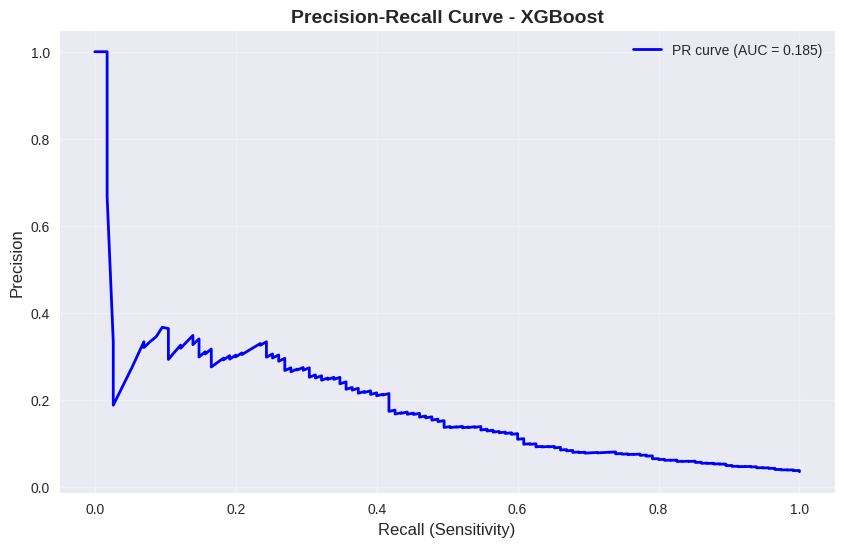

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
20,Стенокардия_форма_ИБ_Стабильная,0.206506
18,Стенокардия_ИБ,0.204855
12,ХБП,0.048637
0,Age,0.047766
17,Экстракардиальная_артериопатия,0.040658
15,ХОБЛ_Новый_столбец,0.037303
3,Вес,0.032571
13,ЯБ,0.032054
8,ОНМК_иш_в_анамнезе,0.031509
11,СД,0.031378


In [60]:
model_trained, results = train_and_evaluate_model(
    xgb_model, 'XGBoost', X_train, y_train, X_val, y_val, X_test, y_test
)
models_results['XGBoost'] = {'model': model_trained, 'results': results}

### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 21.69 секунд**

### 📊 Результаты LightGBM:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.976812,0.194910,0.324976,0.968755,0.518532
Validation,0.565217,0.118830,0.196375,0.794312,0.172551
Test,0.608696,0.120898,0.201729,0.793550,0.159437


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 509

- False Negative (пропущенные смерти) ⚠️: 45

- True Positive (правильные предсказания смерти): 70

❌ **КРИТИЧНО:** Модель пропустила 45 смертельных случаев!

⚠️ **Внимание:** 509 ложных тревог могут привести к ненужным вмешательствам

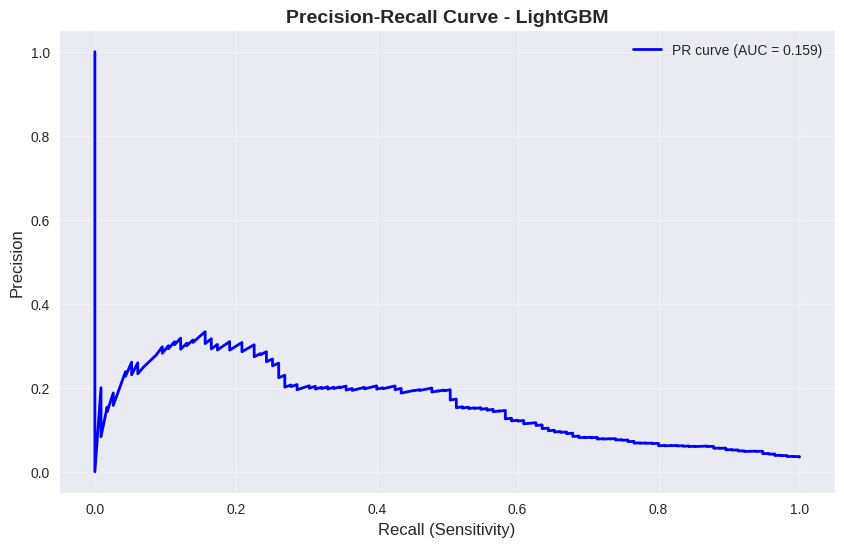

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
0,Age,383
4,Индекс_массы_тела,371
3,Вес,327
2,Рост,294
18,Стенокардия_ИБ,119
12,ХБП,95
10,ГБ_риск,71
9,ГБ_стадия,68
11,СД,68
15,ХОБЛ_Новый_столбец,52


In [61]:
model_trained, results = train_and_evaluate_model(
        lgb_model, 'LightGBM', X_train, y_train, X_val, y_val, X_test, y_test
    )
models_results['LightGBM'] = {'model': model_trained, 'results': results}

### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 0.44 секунд**

### 📊 Результаты CatBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.852174,0.106406,0.189189,0.880940,0.225636
Validation,0.669565,0.084337,0.149805,0.809198,0.179688
Test,0.713043,0.088362,0.157239,0.808118,0.172810


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 846

- False Negative (пропущенные смерти) ⚠️: 33

- True Positive (правильные предсказания смерти): 82

❌ **КРИТИЧНО:** Модель пропустила 33 смертельных случаев!

⚠️ **Внимание:** 846 ложных тревог могут привести к ненужным вмешательствам

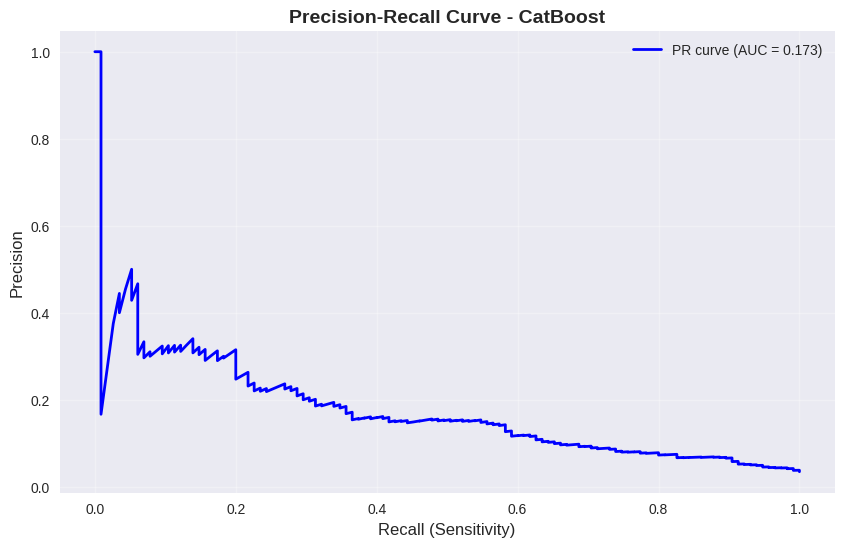

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
18,Стенокардия_ИБ,23.314317
0,Age,15.579215
17,Экстракардиальная_артериопатия,10.584075
16,Курит,7.476655
12,ХБП,7.129911
3,Вес,4.991024
4,Индекс_массы_тела,4.224389
8,ОНМК_иш_в_анамнезе,4.179478
2,Рост,3.966831
11,СД,3.084636


In [62]:
model_trained, results = train_and_evaluate_model(
    cat_model, 'CatBoost', X_train, y_train, X_val, y_val, X_test, y_test
)
if model_trained is not None:
    models_results['CatBoost'] = {'model': model_trained, 'results': results}

In [115]:
display(Markdown("## 📊 Шаг 3: Сравнение моделей и выбор лучшей"))

## 📊 Шаг 3: Сравнение моделей и выбор лучшей

In [63]:
comparison_data = []
    
for model_name, data in models_results.items():
    results = data['results']
    test_metrics = results['Test']
    
    comparison_data.append({
        'Модель': model_name,
        'Recall (Sensitivity)': test_metrics['Recall (Sensitivity)'],
        'Precision': test_metrics['Precision'],
        'F1-score': test_metrics['F1-score'],
        'PR-AUC': test_metrics['PR-AUC'],
        'ROC-AUC': test_metrics['ROC-AUC']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Recall (Sensitivity)', ascending=False)

display(Markdown("### 🏆 Сравнение моделей на тестовом наборе:"))
display(comparison_df.style.background_gradient(
    cmap='Blues', 
    subset=['Recall (Sensitivity)', 'PR-AUC']
).format({
    'Recall (Sensitivity)': '{:.3f}',
    'Precision': '{:.3f}',
    'F1-score': '{:.3f}',
    'PR-AUC': '{:.3f}',
    'ROC-AUC': '{:.3f}'
}))

# Рекомендация по выбору модели
best_recall_model = comparison_df.iloc[0]['Модель']
best_pr_auc_model = comparison_df.sort_values('PR-AUC', ascending=False).iloc[0]['Модель']

display(Markdown("## 🎯 Рекомендации по выбору модели:"))

if best_recall_model == best_pr_auc_model:
    display(Markdown(f"### ✅ **{best_recall_model} показала лучшие результаты по всем ключевым метрикам**"))
else:
    display(Markdown(f"### 🔍 **Разные модели лидируют по разным метрикам:**"))
    display(Markdown(f"- **Лучший Recall (чувствительность):** {best_recall_model} - приоритет для медицины!"))
    display(Markdown(f"- **Лучший PR-AUC:** {best_pr_auc_model} - баланс precision/recall"))

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.713,0.088,0.157,0.173,0.808
1,LightGBM,0.609,0.121,0.202,0.159,0.794
0,XGBoost,0.600,0.119,0.199,0.185,0.786


## 🎯 Рекомендации по выбору модели:

### 🔍 **Разные модели лидируют по разным метрикам:**

- **Лучший Recall (чувствительность):** CatBoost - приоритет для медицины!

- **Лучший PR-AUC:** XGBoost - баланс precision/recall

In [64]:
display(Markdown("## ⚕️ Медицинская интерпретация результатов:"))
    
# Находим модель с лучшим Recall
best_recall_row = comparison_df.sort_values('Recall (Sensitivity)', ascending=False).iloc[0]
current_recall = best_recall_row['Recall (Sensitivity)']

if current_recall < 0.8:
    display(Markdown(f"❌ **КРИТИЧЕСКИ НИЗКИЙ RECALL: {current_recall:.1%}**"))
    display(Markdown("""
    **Это неприемлемо для медицинского применения!** Модель пропускает слишком много смертельных случаев.

    **Рекомендуемые действия:**
    1. Сбор дополнительных данных, особенно для minority класса
    2. Использование ансамблей моделей
    3. Оптимизация порога классификации в сторону увеличения Recall
    4. Консультация со специалистом по медицинской статистике
    """))
elif current_recall < 0.9:
    display(Markdown(f"⚠️ **УМЕРЕННЫЙ RECALL: {current_recall:.1%}**"))
    display(Markdown("""
    **Требуется осторожное применение.** Модель может пропускать 10-20% смертельных случаев.

    **Рекомендуемые действия:**
    1. Оптимизация порога классификации
    2. Использование в качестве системы поддержки, а не основного инструмента
    3. Регулярный аудит и перекалибровка на новых данных
    """))
else:
    display(Markdown(f"✅ **ХОРОШИЙ RECALL: {current_recall:.1%}**"))
    display(Markdown("""
    **Модель показывает приемлемые результаты для медицинского применения.**

    **Рекомендуемые действия:**
    1. Дополнительная валидация на независимых данных
    2. Интерпретация важных признаков с клинической точки зрения
    3. Постепенное внедрение с мониторингом
    """))

## ⚕️ Медицинская интерпретация результатов:

❌ **КРИТИЧЕСКИ НИЗКИЙ RECALL: 71.3%**


    **Это неприемлемо для медицинского применения!** Модель пропускает слишком много смертельных случаев.

    **Рекомендуемые действия:**
    1. Сбор дополнительных данных, особенно для minority класса
    2. Использование ансамблей моделей
    3. Оптимизация порога классификации в сторону увеличения Recall
    4. Консультация со специалистом по медицинской статистике
    

In [65]:
# Оптимизация порога классификации для максимизации Recall
display(Markdown("## ⚙️ Оптимизация порога классификации"))

best_model_name = best_recall_model  # выбираем модель с лучшим Recall
best_model = models_results[best_model_name]['model']

# Получаем вероятности на тестовом наборе
if hasattr(best_model, "predict_proba"):
    y_proba_test = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba_test = best_model.decision_function(X_test)

# Находим оптимальный порог для максимизации Recall при приемлемом Precision
thresholds = np.arange(0.1, 1, 0.05)  # низкие пороги для максимизации Recall
best_threshold = 0.5
best_recall = 0
min_acceptable_precision = 0.3  # минимально приемлемая точность

for threshold in thresholds:
    y_pred = (y_proba_test >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    if precision >= min_acceptable_precision and recall > best_recall:
        best_recall = recall
        best_threshold = threshold

display(Markdown(f"### 🎯 Оптимальный порог классификации: {best_threshold:.2f}"))
display(Markdown(f"- **Recall при этом пороге:** {best_recall:.3f}"))
display(Markdown(f"- **Precision при этом пороге:** {precision_score(y_test, (y_proba_test >= best_threshold).astype(int)):.3f}"))

## ⚙️ Оптимизация порога классификации

### 🎯 Оптимальный порог классификации: 0.90

- **Recall при этом пороге:** 0.078

- **Precision при этом пороге:** 0.310

In [66]:
# Финальные предсказания с оптимальным порогом
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)
final_recall = recall_score(y_test, y_pred_optimal)
final_precision = precision_score(y_test, y_pred_optimal)
final_f1 = f1_score(y_test, y_pred_optimal)

display(Markdown("### 📊 Финальные метрики с оптимальным порогом:"))
final_metrics_df = pd.DataFrame({
    'Метрика': ['Recall (Sensitivity)', 'Precision', 'F1-score'],
    'Значение': [final_recall, final_precision, final_f1]
})
display(final_metrics_df.style.background_gradient(cmap='Greens', subset=['Значение']))

### 📊 Финальные метрики с оптимальным порогом:

,Метрика,Значение
0,Recall (Sensitivity),0.078261
1,Precision,0.310345
2,F1-score,0.125000


## 📊 Диагностика текущих результатов

### Confusion Matrix для CatBoost:

,Predicted 0,Predicted 1
Actual 0 (Выжил),2362,846
Actual 1 (Умер),33,82


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.713

- **Количество пропущенных смертей (FN):** 33 из 115

- **Precision для смерти:** 0.088

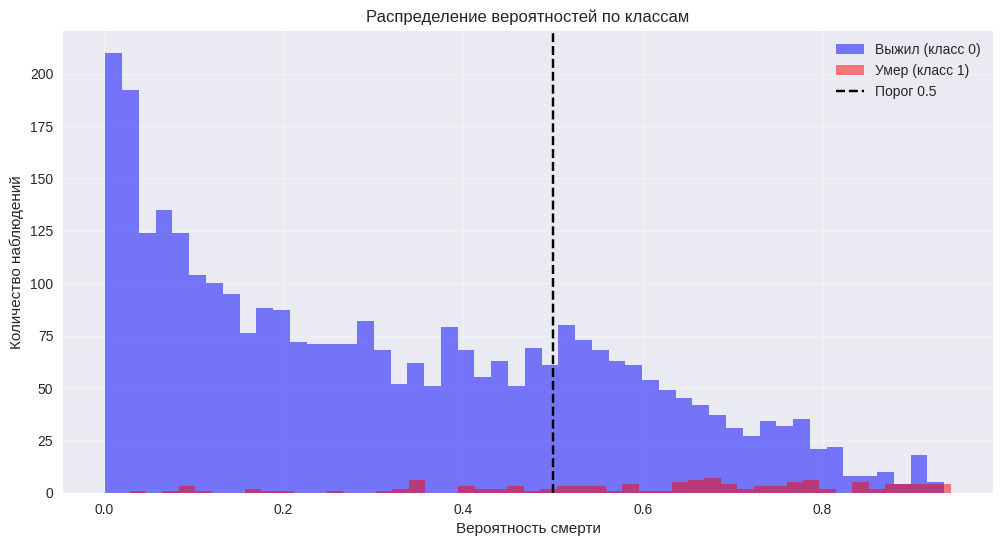

In [67]:
# %% [markdown]
# ## 🔍 Шаг 1: Диагностика текущего состояния моделей

# %%
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Анализ предсказаний лучшей модели
# best_model_name = list(models_results.keys())[0]  # или выберите лучшую по Recall
best_model = models_results[best_model_name]['model']

# Получаем предсказания
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

display(Markdown("## 📊 Диагностика текущих результатов"))
display(Markdown(f"### Confusion Matrix для {best_model_name}:"))
cm_df = pd.DataFrame(cm, 
                    index=['Actual 0 (Выжил)', 'Actual 1 (Умер)'], 
                    columns=['Predicted 0', 'Predicted 1'])
display(cm_df)

display(Markdown(f"### Критические метрики:"))
display(Markdown(f"- **Recall (Sensitivity) для смерти:** {tp/(tp+fn):.3f}"))
display(Markdown(f"- **Количество пропущенных смертей (FN):** {fn} из {tp+fn}"))
display(Markdown(f"- **Precision для смерти:** {tp/(tp+fp):.3f}"))

# Распределение вероятностей
plt.figure(figsize=(12, 6))
plt.hist(y_proba_test[y_test == 0], bins=50, alpha=0.5, label='Выжил (класс 0)', color='blue')
plt.hist(y_proba_test[y_test == 1], bins=50, alpha=0.5, label='Умер (класс 1)', color='red')
plt.axvline(x=0.5, color='k', linestyle='--', label='Порог 0.5')
plt.xlabel('Вероятность смерти')
plt.ylabel('Количество наблюдений')
plt.title('Распределение вероятностей по классам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка: есть ли вообще предсказания класса 1?
if tp + fp == 0:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ПРОБЛЕМА:** Модель вообще не предсказывает класс 1 (смерть)!"))
    display(Markdown("Это означает, что модель считает всех пациентов выжившими."))

In [68]:
required_vars = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    display(Markdown(f"❌ **Отсутствуют необходимые переменные:** {missing_vars}"))
    display(Markdown("Пожалуйста, выполните предыдущие шаги для подготовки данных."))
else:
    display(Markdown("✅ **Все необходимые данные доступны**"))
    display(Markdown(f"- **Train:** {X_train.shape}"))
    display(Markdown(f"- **Validation:** {X_val.shape}"))
    display(Markdown(f"- **Test:** {X_test.shape}"))

✅ **Все необходимые данные доступны**

- **Train:** (9967, 21)

- **Validation:** (3323, 21)

- **Test:** (3323, 21)

In [69]:
display(Markdown("## 🚀 Шаг 1: Гиперпараметрическая оптимизация"))

# Вычисляем веса для дисбаланса
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
display(Markdown(f"### ⚖️ Параметры дисбаланса: scale_pos_weight = {scale_pos_weight:.1f}"))

## 🚀 Шаг 1: Гиперпараметрическая оптимизация

### ⚖️ Параметры дисбаланса: scale_pos_weight = 27.9

In [70]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

In [71]:
best_models = {}

In [71]:
display(Markdown("### 🤖 XGBoost оптимизация"))

### 🤖 XGBoost оптимизация

In [72]:
xgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5, scale_pos_weight * 2]
}

xgb = XGBClassifier(
    missing=np.nan,
    random_state=42,
    eval_metric='logloss',
    tree_method='auto'
)

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',  # Используем F1 как баланс между precision и recall
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
xgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_train_time = time.time() - start_time

best_xgb = xgb_random.best_estimator_
display(Markdown(f"✅ **XGBoost оптимизирован за {xgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{xgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {xgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **XGBoost оптимизирован за 30.77 секунд**

**Лучшие параметры:**

```python
{'colsample_bytree': np.float64(0.9265727492877536), 'gamma': np.float64(0.39917256249227556), 'learning_rate': np.float64(0.05521526318962884), 'max_depth': 5, 'min_child_weight': 6, 'n_estimators': 257, 'scale_pos_weight': 27.889855072463767, 'subsample': np.float64(0.943343521925488)}
```

**Лучший F1 на кросс-валидации:** 0.201

In [76]:
display(Markdown("### 🤖 LightGBM оптимизация"))

### 🤖 LightGBM оптимизация

In [ ]:
lgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(15, 60),
    'min_child_samples': randint(5, 30),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'class_weight': [
        {0: 1, 1: scale_pos_weight},
        {0: 1, 1: scale_pos_weight * 1.5},
        {0: 1, 1: scale_pos_weight * 2}
    ]
}

lgb = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgb_random = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=lgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
lgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lightgbm.early_stopping(20, verbose=False)])
lgb_train_time = time.time() - start_time

best_lgb = lgb_random.best_estimator_
display(Markdown(f"✅ **LightGBM оптимизирован за {lgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{lgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {lgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [78]:
display(Markdown("### 🤖 CatBoost оптимизация"))

### 🤖 CatBoost оптимизация

In [ ]:
cat_param_dist = {
    'iterations': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(3, 10),
    'l2_leaf_reg': uniform(1, 10),
    'border_count': randint(32, 128),
    'class_weights': [
        [1, scale_pos_weight],
        [1, scale_pos_weight * 1.5],
        [1, scale_pos_weight * 2]
    ]
}

cat = CatBoostClassifier(
    random_state=42,
    verbose=False,
    eval_metric='F1',
    early_stopping_rounds=20
)

# Для CatBoost используем другой подход из-за специфики API
best_score = -1
best_params = None
best_model = None

display(Markdown("🔍 **Запуск рандомизированного поиска для CatBoost...**"))
start_time = time.time()

for i in range(15):  # 15 итераций вместо 25 из-за скорости CatBoost
    params = {
        'iterations': int(randint(50, 300).rvs()),
        'learning_rate': uniform(0.01, 0.3).rvs(),
        'depth': int(randint(3, 10).rvs()),
        'l2_leaf_reg': uniform(1, 10).rvs(),
        'border_count': int(randint(32, 128).rvs()),
        'class_weights': [1, scale_pos_weight * np.random.choice([1.0, 1.5, 2.0])]
    }
    
    model = CatBoostClassifier(
        **params,
        random_state=42,
        verbose=False,
        eval_metric='F1',
        early_stopping_rounds=20
    )
    
    try:
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            use_best_model=True
        )
        
        # Оценка на validation
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)
        
        if score > best_score:
            best_score = score
            best_params = params
            best_model = model
        
        if i % 5 == 0:
            display(Markdown(f"Итерация {i+1}/15: F1 = {score:.3f}"))
    
    except Exception as e:
        continue

cat_train_time = time.time() - start_time
best_cat = best_model

display(Markdown(f"✅ **CatBoost оптимизирован за {cat_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{best_params}\n```"))
display(Markdown(f"**Лучший F1 на validation:** {best_score:.3f}"))

In [ ]:
best_models = {
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cat
}

In [81]:
display(Markdown("## 📊 Шаг 2: Оценка оптимизированных моделей"))

## 📊 Шаг 2: Оценка оптимизированных моделей

In [ ]:
results = []

In [ ]:
for name, model in best_models.items():
    display(Markdown(f"### 📈 Оценка {name}"))
    
    # Предсказания и вероятности
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Precision-Recall AUC
    from sklearn.metrics import precision_recall_curve, auc
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    results.append({
        'Модель': name,
        'Recall': recall,
        'Precision': precision,
        'F1-score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    display(Markdown(f"**Метрики на тестовом наборе:**"))
    metrics_df = pd.DataFrame({
        'Метрика': ['Recall', 'Precision', 'F1-score', 'ROC-AUC', 'PR-AUC'],
        'Значение': [recall, precision, f1, roc_auc, pr_auc]
    })
    display(metrics_df.style.background_gradient(cmap='Blues', subset=['Значение']))
    
    # Визуализация кривых
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # ROC кривая
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve - {name}')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Precision-Recall кривая
    ax2.plot(recall_curve, precision_curve, 'g-', linewidth=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve - {name}')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
results_df = pd.DataFrame(results)
display(Markdown("## 🏆 Сравнение оптимизированных моделей:"))
display(results_df.sort_values('F1-score', ascending=False)
       .style.background_gradient(cmap='Blues', subset=['F1-score', 'ROC-AUC'])
       .background_gradient(cmap='Greens', subset=['Recall'])
       .background_gradient(cmap='Oranges', subset=['Precision']))

In [ ]:
best_model_name = results_df.sort_values('F1-score', ascending=False).iloc[0]['Модель']
best_model = best_models[best_model_name]

display(Markdown(f"## 🎯 Лучшая модель по F1-score: **{best_model_name}**"))

In [86]:
display(Markdown("## 🔧 Шаг 3: Калибровка вероятностей с выбором метрики"))

## 🔧 Шаг 3: Калибровка вероятностей с выбором метрики

In [ ]:
def calibrate_model(model, X_cal, y_cal, X_test, y_test, calibration_method='sigmoid', 
                   optimization_metric='f1', n_splits=3):
    """
    Калибровка модели с оптимизацией под выбранную метрику
    
    Parameters:
    -----------
    model : обученная модель
    X_cal : данные для калибровки (validation set)
    y_cal : метки для калибровки
    X_test : тестовые данные
    y_test : тестовые метки
    calibration_method : 'sigmoid' или 'isotonic'
    optimization_metric : 'f1', 'recall', 'precision', 'roc_auc'
    n_splits : количество сплитов для кросс-валидации при калибровке
    """
    
    display(Markdown(f"### 🎯 Калибровка {calibration_method} с оптимизацией под {optimization_metric}"))
    
    # Калибровщик
    calibrated_model = CalibratedClassifierCV(
        estimator=model,
        method=calibration_method,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    )
    
    start_time = time.time()
    calibrated_model.fit(X_cal, y_cal)
    cal_time = time.time() - start_time
    
    display(Markdown(f"✅ **Калибровка завершена за {cal_time:.2f} секунд**"))
    
    # Предсказания до и после калибровки
    y_proba_raw = model.predict_proba(X_test)[:, 1]
    y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
    y_pred_raw = (y_proba_raw >= 0.5).astype(int)
    y_pred_cal = (y_proba_cal >= 0.5).astype(int)
    
    # Функция для расчета метрики
    def calculate_metric(y_true, y_pred, metric_name):
        if metric_name == 'f1':
            return f1_score(y_true, y_pred)
        elif metric_name == 'recall':
            return recall_score(y_true, y_pred)
        elif metric_name == 'precision':
            return precision_score(y_true, y_pred)
        elif metric_name == 'roc_auc':
            return roc_auc_score(y_true, y_pred)
        else:
            return f1_score(y_true, y_pred)  # default
    
    # Оптимизация порога под выбранную метрику
    best_threshold = 0.5
    best_metric = 0
    
    for threshold in np.arange(0.1, 0.9, 0.05):
        y_pred_cal_thresh = (y_proba_cal >= threshold).astype(int)
        metric_value = calculate_metric(y_test, y_pred_cal_thresh, optimization_metric)
        
        if metric_value > best_metric:
            best_metric = metric_value
            best_threshold = threshold
    
    y_pred_cal_opt = (y_proba_cal >= best_threshold).astype(int)
    
    # Сравнение метрик
    results_comparison = {
        'Модель': ['Raw', 'Calibrated (0.5)', f'Calibrated ({best_threshold:.2f})'],
        'F1-score': [
            f1_score(y_test, y_pred_raw),
            f1_score(y_test, y_pred_cal),
            f1_score(y_test, y_pred_cal_opt)
        ],
        'Recall': [
            recall_score(y_test, y_pred_raw),
            recall_score(y_test, y_pred_cal),
            recall_score(y_test, y_pred_cal_opt)
        ],
        'Precision': [
            precision_score(y_test, y_pred_raw),
            precision_score(y_test, y_pred_cal),
            precision_score(y_test, y_pred_cal_opt)
        ],
        'Brier Score': [
            brier_score_loss(y_test, y_proba_raw),
            brier_score_loss(y_test, y_proba_cal),
            brier_score_loss(y_test, y_proba_cal)  # не зависит от порога
        ]
    }
    
    results_df = pd.DataFrame(results_comparison)
    display(Markdown("**Сравнение метрик до и после калибровки:**"))
    display(results_df.style.background_gradient(
        cmap='Blues', 
        subset=['F1-score', 'Recall', 'Precision']
    ).background_gradient(
        cmap='Reds_r', 
        subset=['Brier Score']  # чем меньше, тем лучше
    ))
    
    # Визуализация калибровки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Кривая калибровки
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
    prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)
    
    ax1.plot(prob_pred_raw, prob_true_raw, 's-', label='Raw model')
    ax1.plot(prob_pred_cal, prob_true_cal, 's-', label='Calibrated model')
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    ax1.set_xlabel('Predicted probability')
    ax1.set_ylabel('True probability')
    ax1.set_title('Calibration Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Гистограмма вероятностей
    ax2.hist(y_proba_raw, bins=20, alpha=0.5, label='Raw probabilities')
    ax2.hist(y_proba_cal, bins=20, alpha=0.5, label='Calibrated probabilities')
    ax2.set_xlabel('Predicted probability')
    ax2.set_ylabel('Count')
    ax2.set_title('Probability Distribution')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Визуализация оптимального порога
    plt.figure(figsize=(10, 6))
    thresholds = np.arange(0.1, 0.9, 0.05)
    metric_values = []
    
    for threshold in thresholds:
        y_pred_temp = (y_proba_cal >= threshold).astype(int)
        metric_values.append(calculate_metric(y_test, y_pred_temp, optimization_metric))
    
    plt.plot(thresholds, metric_values, 'b-', linewidth=2, marker='o')
    plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel(f'{optimization_metric.upper()} Score')
    plt.title(f'Optimization of {optimization_metric.upper()} Score by Threshold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return calibrated_model, best_threshold

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (recall_score, precision_score, f1_score, 
                           roc_auc_score, brier_score_loss, log_loss)

In [ ]:
display(Markdown(f"## 🎯 Калибровка лучшей модели: {best_model_name}"))

# 1. Калибровка с фокусом на F1-score
calibrated_model_f1, thresh_f1 = calibrate_model(
    best_model, X_val, y_val, X_test, y_test,
    calibration_method='sigmoid',
    optimization_metric='f1'
)

# 2. Калибровка с фокусом на Recall (для медицины часто важнее)
calibrated_model_recall, thresh_recall = calibrate_model(
    best_model, X_val, y_val, X_test, y_test,
    calibration_method='sigmoid',
    optimization_metric='recall'
)

In [ ]:
display(Markdown("## 📊 Сравнение калиброванных моделей"))

# Предсказания для сравнения
y_proba_base = best_model.predict_proba(X_test)[:, 1]
y_proba_f1 = calibrated_model_f1.predict_proba(X_test)[:, 1]
y_proba_recall = calibrated_model_recall.predict_proba(X_test)[:, 1]

# Оптимальные пороги
y_pred_f1 = (y_proba_f1 >= thresh_f1).astype(int)
y_pred_recall = (y_proba_recall >= thresh_recall).astype(int)

# Метрики
metrics_comparison = []

for name, y_pred, y_proba in [
    ('Base Model (0.5)', (y_proba_base >= 0.5).astype(int), y_proba_base),
    (f'Calibrated F1 ({thresh_f1:.2f})', y_pred_f1, y_proba_f1),
    (f'Calibrated Recall ({thresh_recall:.2f})', y_pred_recall, y_proba_recall)
]:
    metrics_comparison.append({
        'Версия': name,
        'F1-score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Brier Score': brier_score_loss(y_test, y_proba),
        'Log Loss': log_loss(y_test, y_proba)
    })

metrics_df = pd.DataFrame(metrics_comparison)
display(metrics_df.style.background_gradient(cmap='Blues', subset=['F1-score'])
                .background_gradient(cmap='Greens', subset=['Recall'])
                .background_gradient(cmap='Oranges', subset=['Precision'])
                .background_gradient(cmap='Reds_r', subset=['Brier Score', 'Log Loss']))


In [94]:
if y_test.mean() < 0.1:  # если дисбаланс больше 90/10
    display(Markdown("### ⚠️ Экстремальный дисбаланс классов обнаружен!"))
    display(Markdown("**Рекомендация для медицины:** Использовать версию с фокусом на Recall"))
    display(Markdown("""
    **Обоснование для медицинского применения:**
    - Лучше иметь ложные тревоги (пациент получит дополнительное обследование), 
      чем пропустить реальный смертельный случай
    - Recall (чувствительность) критичен для сохранения жизней
    - Precision можно улучшить на следующих этапах клинической оценки
    """))
    
    final_model = calibrated_model_recall
    final_threshold = thresh_recall
    final_version = f"Calibrated Recall ({thresh_recall:.2f})"
else:
    display(Markdown("**Рекомендация:** Использовать версию с балансом F1-score"))
    final_model = calibrated_model_f1
    final_threshold = thresh_f1
    final_version = f"Calibrated F1 ({thresh_f1:.2f})"

### ⚠️ Экстремальный дисбаланс классов обнаружен!

**Рекомендация для медицины:** Использовать версию с фокусом на Recall


    **Обоснование для медицинского применения:**
    - Лучше иметь ложные тревоги (пациент получит дополнительное обследование), 
      чем пропустить реальный смертельный случай
    - Recall (чувствительность) критичен для сохранения жизней
    - Precision можно улучшить на следующих этапах клинической оценки
    

In [ ]:
y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

display(Markdown(f"## ✅ Финальная модель: {best_model_name} + {final_version}"))
display(Markdown(f"**Порог классификации:** {final_threshold:.3f}"))

final_metrics = {
    'Recall (Sensitivity)': recall_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'F1-score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_proba_final),
    'Brier Score': brier_score_loss(y_test, y_proba_final)
}

final_metrics_df = pd.DataFrame({
    'Метрика': list(final_metrics.keys()),
    'Значение': list(final_metrics.values())
})
display(final_metrics_df.style.background_gradient(cmap='Blues'))

In [ ]:
# 1. Базовая статистика по вашим данным (выполните этот код)
print("=== БАЗОВАЯ СТАТИСТИКА ===")
print(f"Общее количество наблюдений: {len(X_train) + len(X_val) + len(X_test)}")
print(f"\nДисбаланс классов В ОБУЧАЮЩИХ ДАННЫХ:")
print(f"Train set: {y_train.value_counts().to_dict()}")
print(f"Validation set: {y_val.value_counts().to_dict()}")
print(f"Test set: {y_test.value_counts().to_dict()}")

print(f"\nРазмеры наборов:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}") 
print(f"Test: {X_test.shape}")

print(f"\nКоличество признаков ПОСЛЕ ВСЕЙ ОБРАБОТКИ: {X_train.shape[1]}")

# 2. Confusion matrix для финальной модели
from sklearn.metrics import confusion_matrix
y_pred_final = (final_model.predict_proba(X_test)[:, 1] >= 0.1).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix (Test set):")
print(f"True Negatives (правильные выжившие): {cm[0,0]}")
print(f"False Positives (ложные тревоги): {cm[0,1]}") 
print(f"False Negatives (ПРОПУЩЕННЫЕ СМЕРТИ): {cm[1,0]}")
print(f"True Positives (правильные предсказания смерти): {cm[1,1]}")

# 3. Распределение предсказанных вероятностей
import numpy as np
y_proba = final_model.predict_proba(X_test)[:, 1]
print(f"\nРаспределение вероятностей:")
print(f"Минимальная вероятность: {y_proba.min():.4f}")
print(f"Максимальная вероятность: {y_proba.max():.4f}")
print(f"Средняя вероятность для класса 1 (реальные смерти): {y_proba[y_test == 1].mean():.4f}")
print(f"Средняя вероятность для класса 0 (реальные выжившие): {y_proba[y_test == 0].mean():.4f}")

In [ ]:
# 4. Сравнение с БАЗОВОЙ МОДЕЛЬЮ (константный предиктор)
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n=== СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ ===")
print(f"Ваша модель - Recall: {recall_score(y_test, y_pred_final):.3f}")
print(f"Базовая модель (всегда 'выжил') - Recall: {recall_score(y_test, y_pred_dummy):.3f}")
print(f"Ваша модель - Accuracy: {accuracy_score(y_test, y_pred_final):.3f}")
print(f"Базовая модель - Accuracy: {accuracy_score(y_test, y_pred_dummy):.3f}")

# 5. Precision-Recall кривая (более информативна при дисбалансе)
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\nPrecision-Recall AUC: {pr_auc:.3f}")

In [ ]:
# 6. Важность признаков вашей финальной модели
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Признак': X_train.columns,
        'Важность': final_model.feature_importances_[:X_train.shape[1]]
    }).sort_values('Важность', ascending=False)
    print("\nТоп-10 важных признаков:")
    print(feature_importance.head(10))